# Prediksi Konversi Nasabah Deposito Berjangka: Bank Maju Sejahtera (BMS)

## Executive Summary

BMS menghadapi kampanye telemarketing yang secara historis dijalankan tanpa prioritisasi: seluruh nasabah dihubungi tanpa mempertimbangkan siapa yang sebenarnya berpeluang tinggi untuk membuka deposito berjangka. Dari 41.176 baris data historis, hanya 11,27% nasabah yang akhirnya subscribe, artinya sekitar 9 dari 10 panggilan pada pendekatan lama berujung sia-sia. Project ini membangun model klasifikasi untuk memprediksi probabilitas subscribe per nasabah, supaya kampanye bisa diprioritaskan berdasarkan data, bukan urutan acak.

Setelah membersihkan data (menghapus 12 baris duplikat, mempertahankan kategori 'unknown' sebagai sinyal informatif, mengeluarkan kolom `duration` dan `pdays` karena leakage dan redundansi) dan menelusuri pola konversi lewat analisis demografi, channel, riwayat interaksi, waktu kampanye, dan kondisi makroekonomi, project ini membangun cost framework baru yang memperbaiki kesalahan pendekatan sebelumnya: True Positive dinilai +Rp450.000 (bukan nol), karena nasabah yang berhasil dikonversi jelas menghasilkan margin bagi bank, dikurangi biaya panggilan yang merealisasikannya.

Dari benchmark 30 kombinasi model dan strategi resampling (5-fold cross-validation), model **LightGBM dengan RandomOverSampler** terpilih dan di-tuning, mencapai ROC-AUC 0,8165 dan PR-AUC 0,4685 pada test set yang dikunci sejak awal. Threshold keputusan tidak diambil dari titik profit tertinggi secara matematis (0,33), yang ternyata menuntut menghubungi 51,6% database dengan precision hanya 18,7%, bertentangan dengan tujuan prioritisasi kampanye. Sebagai gantinya, threshold **0,40** ditetapkan lewat analisis koridor kapasitas call center (titik diminishing returns dan batas precision minimum 30%), menghasilkan F2 0,5731, Recall 72,7%, dan Precision 31,0%.

Dampak bisnisnya konkret. Net profit pada test set naik dari baseline Rp52.200.000 (skenario menghubungi semua nasabah) menjadi **Rp102.150.000** dengan model, kenaikan 95,7%, sekaligus volume panggilan turun dari 8.236 menjadi 2.177 nasabah, reduksi 73,6%. Diekstrapolasi ke skala kampanye penuh, profit model diproyeksikan sekitar Rp510.700.389, dengan ROI kampanye 93,8%. Angka ekstrapolasi ini bersifat indikatif, dengan asumsi komposisi nasabah dan kondisi pasar pada skala penuh serupa dengan test set, jadi sebaiknya diperlakukan sebagai proyeksi kasar untuk gambaran skala dampak, bukan angka pasti (lihat catatan lengkap di F.4). Model unggul di dua dimensi sekaligus: lebih untung dan lebih efisien, bukan kompromi antara keduanya.

Rekomendasi utama: prioritaskan kontak berdasarkan skor model di atas threshold 0,40, dahulukan nasabah dengan riwayat interaksi positif (`poutcome='success'`, subscribe rate 65,1%) dan channel cellular (14,7% vs 5,2% telephone), dan alokasikan sekitar 71% anggaran kampanye ke lima bulan berkontribusi konversi terbesar (Mei, Agustus, Juli, Juni, April) alih-alih ke bulan ber-rate tinggi namun bervolume kecil seperti Maret atau Desember, yang justru menjadi temuan paling berbeda dari intuisi awam dalam analisis ini.

## A. Business Understanding

### A.1 Background & Context

PT Bank Maju Sejahtera (BMS) mengalami dua fase suku bunga yang berlawanan arah dalam empat tahun terakhir, dan keduanya mengubah daya tarik deposito berjangka di mata nasabah. Pada 2020-2021, Bank Indonesia menekan BI Rate sampai ke titik terendah historis, 3,5%, sebagai respons pemulihan ekonomi pasca pandemi COVID-19. Imbal hasil deposito ikut tertekan, dan dana nasabah lari ke instrumen lain seperti reksa dana pasar uang atau Surat Berharga Negara ritel yang menawarkan kupon lebih kompetitif. Segmen deposito berjangka BMS praktis stagnan di periode ini.

Keadaan berbalik di 2022-2023. Bank Indonesia menaikkan BI Rate secara bertahap sampai 6,0% untuk meredam inflasi, dan deposito kembali jadi instrumen yang menarik bagi nasabah yang mencari imbal hasil pasti dengan risiko rendah. BMS melihat momentum ini sebagai peluang untuk merebut kembali dana yang sempat berpindah, sekaligus menjaring nasabah baru yang belum pernah membuka produk simpanan berjangka di bank ini.

Untuk menangkap peluang tersebut, BMS menjalankan kampanye telemarketing yang menyasar dua segmen: nasabah existing yang portofolionya bisa dialihkan sebagian ke deposito, dan prospek baru dari database calon nasabah. Masalahnya, kampanye semacam ini secara historis dijalankan tanpa prioritisasi, agen menghubungi nasabah secara berurutan tanpa mempertimbangkan siapa yang sebenarnya punya peluang lebih tinggi untuk bilang "ya". Empat pihak di BMS berkepentingan langsung terhadap efisiensi kampanye ini: Chief Marketing Officer (CMO) yang mengalokasikan anggaran dan sumber daya call center, Tim Telemarketing yang menjalankan panggilan harian, Tim Keuangan yang memproyeksikan pertumbuhan Dana Pihak Ketiga (DPK) dari hasil kampanye, dan Chief Risk Officer (CRO) yang memastikan cara penjualan produk investasi ini tetap sesuai koridor regulasi OJK.

Sebelum menetapkan target peningkatan apa pun, kita perlu tahu dulu di mana titik berangkatnya. Baseline yang relevan di sini adalah conversion rate kampanye saat semua nasabah dihubungi tanpa prioritisasi sama sekali, yaitu proporsi nasabah berlabel `yes` di dataset historis. Angka ini akan dihitung langsung dari data pada bagian berikut, dan menjadi pembanding untuk setiap klaim peningkatan yang diajukan project ini nanti.

### A.2 Problem Statement

Sebelum merumuskan problem statement secara presisi, kita perlu angka baseline yang disebutkan di atas. Berikut load dataset historis kampanye BMS dan cek ukurannya serta distribusi target `y`.

In [2]:
import pandas as pd

df = pd.read_csv('bank-additional-full.csv', sep=';')

print(f"Shape: {df.shape}")
df['y'].value_counts(normalize=True)

Shape: (41188, 21)


y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

Dari 41.188 baris data historis kampanye, hanya 11,27% nasabah yang akhirnya berlangganan deposito berjangka (`y = yes`), sisanya 88,73% menolak. Artinya, kalau BMS menghubungi seluruh nasabah tanpa prioritisasi, sekitar 9 dari 10 panggilan akan berakhir tanpa hasil. Angka 11,27% inilah baseline conversion rate yang disebut di bagian sebelumnya.

Dengan baseline itu, problem statement project ini dirumuskan sebagai:

> Bagaimana memprediksi nasabah yang berpotensi membuka deposito berjangka, sehingga BMS bisa meningkatkan efisiensi kampanye dari kondisi baseline saat ini (conversion rate 11,27%, seluruh nasabah dihubungi tanpa prioritisasi)?

Ini adalah masalah klasifikasi biner: target `y` hanya punya dua kelas, `yes` dan `no`, dan tujuannya memprediksi kelas mana yang berlaku untuk tiap nasabah, bukan memprediksi nilai kontinu (sehingga bukan regresi) dan bukan mengelompokkan nasabah tanpa label acuan (sehingga bukan clustering). Label `y` sudah tersedia di data historis, jadi ini murni persoalan supervised learning.

### A.3 Business Goal

Business goal project ini adalah memaksimalkan net profit kampanye telemarketing, bukan sekadar menaikkan conversion rate atau menekan biaya operasional saja.

Alasannya, net profit adalah satu-satunya ukuran yang menggabungkan dua sisi kampanye secara sekaligus. Sisi pertama adalah nilai dari nasabah yang berhasil dikonversi, ini ditangkap oleh Recall karena Recall tinggi berarti model berhasil menjaring sebagian besar nasabah potensial. Sisi kedua adalah efisiensi biaya panggilan yang tidak terbuang percuma, ini ditangkap oleh Precision karena Precision tinggi berarti panggilan yang dilakukan model sebagian besar tepat sasaran. Kalau goal-nya cuma "naikkan conversion rate", sisi biaya panggilan yang sia-sia diabaikan sepenuhnya, model bisa saja disetel untuk menghubungi hampir semua orang. Sebaliknya kalau goal-nya cuma "turunkan biaya call", sisi pendapatan dari nasabah yang terlewat ikut diabaikan, model bisa disetel terlalu konservatif. Net profit memaksa dua sisi ini dipertimbangkan bersama, dalam satu angka Rupiah yang bisa diaudit oleh Tim Keuangan.

Supaya goal ini terukur, bukan sekadar slogan, baseline net profit (skenario menghubungi semua nasabah tanpa model) akan dihitung setelah cost framework selesai dirumuskan pada bagian berikut. Angka itulah yang jadi titik pembanding: peningkatan yang diklaim project ini nanti harus bisa ditunjukkan sebagai selisih di atas baseline tersebut, bukan angka yang berdiri sendiri.

### A.4 Cost Framework (Cost of Errors)

Untuk menghitung net profit, setiap hasil prediksi model perlu diberi nilai Rupiah. Berikut tabel cost of errors berdasarkan empat skenario confusion matrix:

| Tipe | Prediksi | Realita | Skenario | Nilai |
|------|---------|---------|----------|-------|
| True Positive (TP) | Subscribe | Subscribe | Call relevan, nasabah dikonversi | **+Rp 450.000** |
| True Negative (TN) | Tidak | Tidak | Tidak dihubungi, tidak ada biaya | Rp 0 |
| False Positive (FP) | Subscribe | Tidak | Call sia-sia, waktu & biaya terbuang | -Rp 50.000 |
| False Negative (FN) | Tidak | Subscribe | Nasabah potensial terlewat total | -Rp 500.000 |

**Biaya per call.** Gaji telemarketer bank di Indonesia berkisar Rp 3.500.000 sampai Rp 5.000.000 per bulan, dengan kapasitas kerja sekitar 200 panggilan per bulan (10 call per hari x 20 hari kerja). Itu setara Rp 17.500 sampai Rp 25.000 gaji per call. Ditambah overhead seperti biaya VoIP, lisensi CRM, training, dan gaji supervisor yang biasanya menambah sekitar 100% dari komponen gaji, total biaya per call jadi sekitar Rp 35.000 sampai Rp 50.000. Angka Rp 50.000 dipakai sebagai estimasi konservatif (batas atas rentang). Perlu dicatat, seluruh angka biaya call ini adalah estimasi berbasis asumsi umum industri perbankan Indonesia, bukan data operasional internal, karena BMS adalah entitas ilustratif untuk keperluan project ini.

**Margin kotor per nasabah yang berhasil subscribe.** Net Interest Margin (NIM) rata-rata perbankan Indonesia ada di kisaran 4-5% per tahun (data OJK 2022). Dengan asumsi rata-rata nominal deposito nasabah ritel BMS sekitar Rp 50.000.000, gross spread yang dihasilkan adalah Rp 50.000.000 x 4% = Rp 2.000.000 per tahun. Setelah dikurangi biaya operasional bank (rasio BOPO sekitar 75%), margin bersih yang tersisa sekitar Rp 500.000 per nasabah per tahun. Angka NIM 4% dipilih dari batas bawah rentang 4-5%, konsisten dengan pendekatan konservatif yang sama seperti pada estimasi biaya call di atas.

**Koreksi utama dari pendekatan sebelumnya.** True Positive tidak boleh dinilai nol, karena setiap nasabah yang berhasil dikonversi tetap membutuhkan satu kali panggilan (biaya Rp 50.000) untuk merealisasikan margin Rp 500.000 tersebut. Nilai bersih TP yang tepat adalah margin dikurangi biaya realisasinya: Rp 500.000 - Rp 50.000 = **Rp 450.000**. Tanpa koreksi ini, simulasi bisnis apa pun yang dibangun dari cost framework ini akan meremehkan nilai sebenarnya dari setiap konversi yang berhasil, dan bisa mengarahkan model ke threshold yang terlalu konservatif, terlalu sedikit menghubungi nasabah, karena manfaat dari TP tidak pernah dihitung sebagai insentif untuk menjangkau lebih banyak prospek.

Rasio biaya FN terhadap FP tetap 10:1 (Rp 500.000 berbanding Rp 50.000). Implikasinya, False Negative jauh lebih mahal daripada False Positive, sehingga model harus mengutamakan Recall agar tidak banyak melewatkan nasabah potensial. Tapi karena TP sekarang bernilai positif, bukan nol, threshold yang tepat bukan sekadar "sebisa mungkin tangkap semua positif". Titik optimalnya adalah threshold di mana total profit (TP x Rp 450.000 - FP x Rp 50.000 - FN x Rp 500.000) mencapai nilai maksimal. Logika ini yang nanti dipakai saat pencarian threshold optimal di tahap pemodelan, angkanya belum dihitung di sini karena itu perlu prediksi model yang belum ada.

### A.5 Technical Goal

Technical goal project ini diturunkan langsung dari business goal (A.3) dan cost framework (A.4) di atas, bukan ditentukan lebih dulu lalu dicari pembenarannya setelah hasil model diketahui. Urutannya: business goal menuntut net profit maksimal, cost framework menerjemahkan itu jadi nilai Rupiah per jenis kesalahan prediksi, dan technical goal berikut adalah cara membangun model yang bisa dioptimalkan terhadap nilai itu.

1. Membangun model klasifikasi yang menghasilkan skor probabilitas subscribe per nasabah, bukan sekadar label ya/tidak, sehingga nasabah bisa diranking dan Tim Telemarketing bisa memprioritaskan kontak dari skor tertinggi ke terendah.
2. Membangun pipeline machine learning yang bebas data leakage: split data dilakukan secara stratified, resampling untuk class imbalance hanya diterapkan di training fold, dan seluruh preprocessing dibungkus dalam satu pipeline yang sama dengan model.
3. Menangani class imbalance secara sistematis. Proporsi kelas `yes` yang jauh lebih kecil (11,27% dari hasil di A.2) akan diukur presisi dan ditangani di tahap data understanding dan preprocessing.
4. Threshold keputusan (subscribe atau tidak) dioptimalkan terhadap net profit berdasarkan cost framework A.4, bukan terhadap F2-Score atau Recall semata. Ini konsekuensi langsung dari business goal yang menuntut profit sebagai ukuran akhir.
5. F2-Score dan Recall tetap dipakai, tapi posisinya sebagai metrik pendukung untuk seleksi kombinasi model dan teknik resampling saat cross-validation, bukan sebagai tujuan akhir project. Alasannya praktis: menghitung profit exact butuh threshold search yang mahal untuk dilakukan berulang di setiap fold cross-validation. F2 memberi bobot dua kali lipat ke Recall dibanding Precision, sehingga kombinasi model dan resampler yang tinggi F2-nya cenderung juga tampil baik ketika dievaluasi ulang dengan profit function di tahap akhir, meski urutan rankingnya tidak dijamin identik. F2 dipakai sebagai proxy yang murah secara komputasi untuk tahap seleksi, sementara profit function tetap jadi ukuran final yang menentukan threshold produksi.

### A.6 Stakeholder & Goals

| Stakeholder | Kebutuhan | Keterkaitan dengan Technical Goal (A.5) |
|---|---|---|
| Chief Marketing Officer (CMO) | Alokasi anggaran dan sumber daya call center yang lebih efisien, tidak menghabiskan budget untuk menghubungi nasabah yang peluang konversinya rendah | Skor probabilitas per nasabah (poin 1) memungkinkan alokasi anggaran mengikuti ranking prioritas, bukan dibagi rata |
| Tim Telemarketing | Daftar prioritas nasabah yang bisa langsung dipakai untuk urutan kontak harian | Output skor probabilitas (poin 1) dan threshold hasil optimisasi profit (poin 4) langsung diterjemahkan jadi daftar kontak dengan urutan dan batas jelas |
| Tim Keuangan | Estimasi konversi yang bisa dipertanggungjawabkan untuk proyeksi pertumbuhan DPK | Threshold yang dioptimalkan terhadap net profit (poin 4) menghasilkan angka konversi dan biaya yang bisa diaudit dalam Rupiah, bukan sekadar persentase akurasi |
| Chief Risk Officer (CRO) | Kepastian bahwa proses seleksi nasabah tidak melanggar aturan OJK terkait penawaran produk investasi | Pipeline bebas data leakage dan penanganan class imbalance yang sistematis (poin 2 dan 3) menjaga model tetap valid secara metodologis, sehingga keputusan bisnis yang didasarkan padanya bisa dipertanggungjawabkan |

### A.7 Assumptions & Scope

**Assumptions:**
- Biaya per call diasumsikan seragam Rp 50.000 untuk seluruh nasabah, tidak dibedakan berdasarkan lama percakapan, jam kerja, atau kompleksitas produk yang ditawarkan.
- Margin bersih Rp 500.000 per nasabah per tahun diasumsikan seragam untuk seluruh nasabah yang subscribe, meski pada praktiknya nominal deposito tiap nasabah pasti berbeda.
- Nilai bersih TP sebesar Rp 450.000 (margin Rp 500.000 dikurangi biaya call Rp 50.000) diasumsikan berlaku untuk satu kali konversi per nasabah dalam periode kampanye yang dianalisis, tidak memperhitungkan potensi konversi berulang atau perpanjangan deposito di tahun-tahun berikutnya.
- Dataset merepresentasikan hasil kampanye telemarketing pada periode tertentu, dan tiap baris diasumsikan mewakili satu kontak dengan satu nasabah (bukan nasabah yang sama dihubungi berkali-kali dalam data yang tercatat sebagai baris terpisah tanpa keterangan lanjut).
- Kondisi makroekonomi (BI Rate, inflasi) selama periode data dianggap relatif konsisten dengan kondisi yang dijelaskan pada bagian latar belakang, tanpa pergeseran kebijakan moneter besar yang tidak tercermin dalam data.

**Out of scope:**
- Nilai nominal deposito individual per nasabah tidak dijadikan fitur atau target tambahan dalam model, karena kolom tersebut tidak tersedia di dataset dan margin dihitung sebagai rata-rata agregat.
- Data makroekonomi real-time (BI Rate, inflasi terkini) tidak diintegrasikan ke pipeline prediksi karena dataset bersifat historis dan tidak diperbarui otomatis.
- Analisis potensi cross-selling produk lain (KPR, kartu kredit) di luar deposito berjangka tidak dibahas, meski disinggung sebagai nilai tambah yang tidak dikuantifikasi.
- Optimisasi jadwal atau rute panggilan (kapan waktu terbaik menghubungi nasabah) berada di luar cakupan project ini, yang berfokus pada siapa yang dihubungi, bukan kapan atau bagaimana caranya.

## B. Data Understanding

### B.1 Struktur & Tipe Data

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null  float64
 1

In [3]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [4]:
df.describe(include='object')

/var/folders/65/9_7sqz916rxfxy4njsmyvq4r0000gn/T/ipykernel_87766/87514550.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include='object')


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,y
count,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188,41188
unique,12,4,8,3,3,3,2,10,5,3,2
top,admin.,married,university.degree,no,yes,no,cellular,may,thu,nonexistent,no
freq,10422,24928,12168,32588,21576,33950,26144,13769,8623,35563,36548


Dataset punya 21 kolom yang bisa dikelompokkan jadi lima kelompok berdasarkan makna bisnisnya, bukan sekadar tipe data:

- **Demografi & profil nasabah**: `age`, `job`, `marital`, `education`. Ini karakteristik dasar nasabah yang relatif stabil dan sering dipakai sebagai basis segmentasi pemasaran.
- **Status finansial**: `default`, `housing`, `loan`. Menggambarkan beban kredit nasabah saat ini, relevan karena nasabah dengan beban kredit tinggi biasanya punya kapasitas menabung lebih rendah.
- **Kontak kampanye saat ini dan riwayatnya**: `contact`, `month`, `day_of_week`, `duration`, `campaign`, `pdays`, `previous`, `poutcome`. Ini kelompok paling relevan langsung dengan problem statement, karena menggambarkan interaksi telemarketing itu sendiri.
- **Indikator makroekonomi**: `emp.var.rate`, `cons.price.idx`, `cons.conf.idx`, `euribor3m`, `nr.employed`. Menangkap kondisi ekonomi pada saat kontak dilakukan, konsisten dengan konteks BI Rate yang dibahas di A.1, meski di sini datanya berupa indikator zona Euro (bawaan dataset asli) yang diperlakukan sebagai proxy kondisi makro secara umum.
- **Target**: `y`, label subscribe atau tidak.

Dari `df.info()`, seluruh 21 kolom terisi penuh (non-null count sama dengan jumlah baris), jadi tidak ada nilai kosong dalam pengertian NaN standar pandas. Tapi ini belum berarti datanya bersih, karena beberapa kolom kategorikal memakai string `'unknown'` sebagai placeholder dan `pdays` memakai nilai sentinel 999, keduanya baru terlihat lewat pengecekan nilai isi, bukan lewat `info()`. Ini yang diperiksa di B.3.

### B.2 Kualitas Data: Duplikat

In [5]:
dup_count = df.duplicated().sum()
print(f"Jumlah baris duplikat penuh: {dup_count}")
print(f"Persentase dari total baris: {dup_count / len(df) * 100:.2f}%")

Jumlah baris duplikat penuh: 12
Persentase dari total baris: 0.03%


Baris yang identik di seluruh 21 kolom sekaligus punya kemungkinan sangat kecil untuk merepresentasikan dua nasabah berbeda yang kebetulan sama persis pada demografi, status finansial, riwayat kontak, dan indikator makro pada waktu yang sama. Lebih masuk akal ini adalah artefak pencatatan, misalnya baris yang tercatat dua kali karena kegagalan sistem saat sinkronisasi data. Kalau dibiarkan, baris duplikat ini akan membuat model belajar pola tertentu seolah muncul lebih sering dari yang sebenarnya, membiaskan distribusi fitur maupun target. Baris ini akan dihapus, eksekusinya di C.1.

### B.3 Kualitas Data: Missing & Placeholder 'unknown'

In [6]:
cat_unknown_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan']
unknown_summary = pd.DataFrame({
    'jumlah_unknown': [(df[c] == 'unknown').sum() for c in cat_unknown_cols],
}, index=cat_unknown_cols)
unknown_summary['persentase_%'] = (unknown_summary['jumlah_unknown'] / len(df) * 100).round(2)
unknown_summary = unknown_summary.sort_values('jumlah_unknown', ascending=False)
unknown_summary

,jumlah_unknown,persentase_%
default,8597,20.87
education,1731,4.20
housing,990,2.40
loan,990,2.40
job,330,0.80
marital,80,0.19


In [7]:
pdays_sentinel = (df['pdays'] == 999).sum()
print(f"Baris dengan pdays == 999 (belum pernah dihubungi sebelumnya): {pdays_sentinel}")
print(f"Persentase dari total baris: {pdays_sentinel / len(df) * 100:.2f}%")

Baris dengan pdays == 999 (belum pernah dihubungi sebelumnya): 39673
Persentase dari total baris: 96.32%


In [8]:
subscribe_rate_default = df.groupby('default')['y'].apply(lambda s: (s == 'yes').mean() * 100).round(2)
subscribe_rate_default

default
no         12.88
unknown     5.15
yes         0.00
Name: y, dtype: float64

Kolom `default` punya proporsi `'unknown'` paling besar (lihat tabel di atas), jadi ini kandidat paling kuat untuk dicek apakah placeholder-nya acak atau membawa sinyal. Hasilnya di atas menunjukkan subscribe rate nasabah dengan `default='no'` sekitar 12,88%, lebih dari dua kali lipat dibanding `default='unknown'` yang sekitar 5,15%, sementara `default='yes'` (jumlahnya sangat sedikit) subscribe rate-nya nol. Selisih sebesar ini antar kategori tidak konsisten dengan pola random, artinya status `'unknown'` pada kolom `default` bukan sekadar data hilang secara acak (MCAR), melainkan membawa informasi tersendiri, kemungkinan nasabah yang menyembunyikan atau tidak melaporkan status gagal bayar cenderung berperilaku beda dari nasabah yang statusnya jelas.

Dengan temuan ini, strategi untuk seluruh kolom kategorikal berplaceholder `'unknown'` (`job`, `marital`, `education`, `default`, `housing`, `loan`) adalah: **dipertahankan sebagai kategori tersendiri**, tidak diimputasi ke modus atau kategori lain, dan tidak dihapus barisnya. Menghapus atau mengimputasi `'unknown'` di sini berarti membuang sinyal prediktif yang justru berguna, bertentangan dengan technical goal yang menuntut model menangkap probabilitas subscribe seakurat mungkin. Kategori ini akan ikut di-encode sebagai level tersendiri saat preprocessing nanti.

Sentinel `999` di `pdays` juga bukan missing dalam arti sebenarnya, melainkan kode yang sengaja dipakai dataset untuk menandai "belum pernah dihubungi sebelum kampanye ini". Dengan 96,32% baris bernilai 999, kolom ini secara praktis lebih berguna sebagai sinyal biner (pernah dihubungi atau belum) daripada sebagai angka kontinu, karena skala 999 akan mendominasi perhitungan jarak atau split model kalau dipakai apa adanya. Ini jadi dasar pembuatan fitur `was_contacted_before` di C.4.

### B.4 Distribusi Target & Class Imbalance

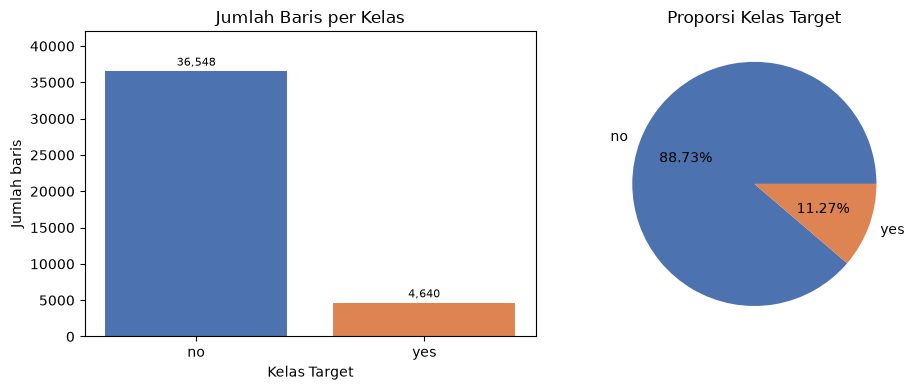

y
no     88.73
yes    11.27
Name: proportion, dtype: float64


In [3]:
import matplotlib.pyplot as plt

target_counts = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
bars = axes[0].bar(target_counts.index, target_counts.values, color=['#4C72B0', '#DD8452'])
axes[0].set_xlabel('Kelas Target')
axes[0].set_title('Jumlah Baris per Kelas')
axes[0].set_ylabel('Jumlah baris')
axes[0].bar_label(bars, labels=[f'{v:,.0f}' for v in target_counts.values], fontsize=8, padding=2)
axes[0].set_ylim(0, target_counts.values.max() * 1.15)
axes[1].pie(target_pct.values, labels=target_pct.index, autopct='%.2f%%', colors=['#4C72B0', '#DD8452'])
axes[1].set_title('Proporsi Kelas Target')
plt.tight_layout()
plt.show()

print(target_pct.round(2))

Distribusi target `y` timpang jauh: kelas `no` mendominasi, kelas `yes` minoritas (angka persisnya tampil di output di atas, konsisten dengan yang sudah dihitung di A.2). Implikasinya langsung ke pemilihan metrik evaluasi. Model yang selalu memprediksi `no` untuk semua nasabah akan mencapai accuracy setinggi proporsi kelas `no` itu sendiri, tapi model semacam ini gagal total secara bisnis karena tidak menangkap satu pun nasabah yang berpotensi subscribe, padahal itulah target sebenarnya dari kampanye. Accuracy jadi metrik yang menyesatkan di kasus ini, dan tidak dipakai sebagai acuan utama.

Imbalance ini juga jadi alasan langsung technical goal poin 3 di A.5: penanganan class imbalance secara sistematis diperlukan supaya model tidak bias ke kelas mayoritas saat training, bukan cuma soal metrik evaluasi tapi juga soal bagaimana model dilatih.

### B.5 Distribusi Fitur Numerik & Deteksi Anomali

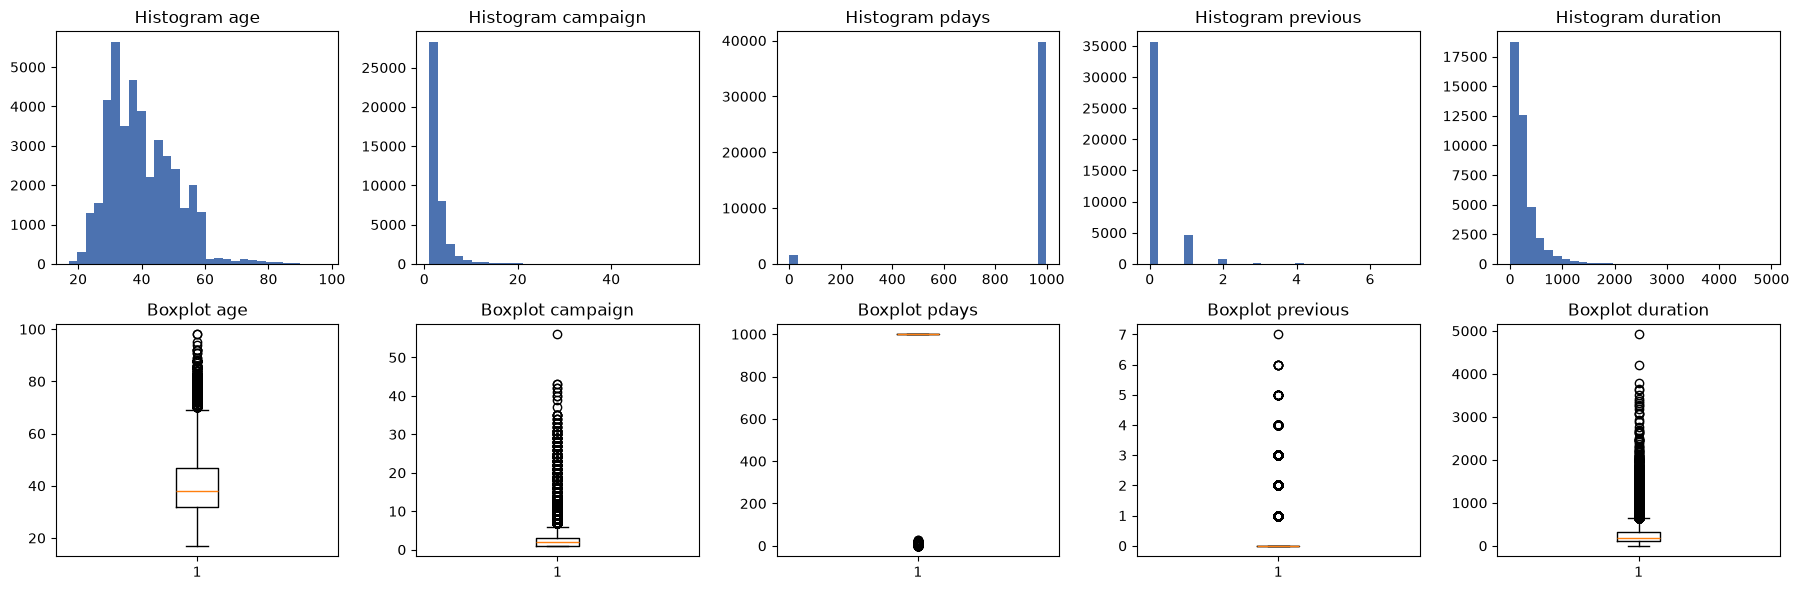

,age,campaign,pdays,previous,duration
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,258.285010
std,10.42125,2.770014,186.910907,0.494901,259.279249
min,17.00000,1.000000,0.000000,0.000000,0.000000
25%,32.00000,1.000000,999.000000,0.000000,102.000000
50%,38.00000,2.000000,999.000000,0.000000,180.000000
75%,47.00000,3.000000,999.000000,0.000000,319.000000
max,98.00000,56.000000,999.000000,7.000000,4918.000000


In [10]:
numeric_cols = ['age', 'campaign', 'pdays', 'previous', 'duration']
fig, axes = plt.subplots(2, len(numeric_cols), figsize=(18, 6))

for i, col in enumerate(numeric_cols):
    axes[0, i].hist(df[col], bins=30, color='#4C72B0')
    axes[0, i].set_title(f'Histogram {col}')
    axes[1, i].boxplot(df[col])
    axes[1, i].set_title(f'Boxplot {col}')

plt.tight_layout()
plt.show()

df[numeric_cols].describe()

Dua kolom menunjukkan pola anomali yang jelas dari statistik dan grafik di atas:

- **`campaign`** berekor sangat panjang ke kanan: median jauh di bawah nilai maksimumnya, artinya sebagian besar nasabah dihubungi hanya beberapa kali dalam satu kampanye, tapi ada segelintir baris dengan puluhan kali kontak. Ekor ekstrem ini kandidat kuat untuk capping, keputusannya di C.3.
- **`pdays`** didominasi nilai sentinel 999 sesuai temuan di B.3, sehingga histogram dan boxplot-nya nyaris seluruhnya menumpuk di satu titik, bukan distribusi kontinu yang wajar untuk diukur pakai statistik biasa (mean, std jadi tidak informatif untuk kolom ini apa adanya).

Bagian ini baru mendiagnosa, belum melakukan tindakan cleaning apa pun, keputusan cleaning-nya menyusul di bagian pembersihan data berikut (C.3 untuk campaign, C.5 untuk duration).

Satu catatan khusus untuk `duration`: kolom ini ditampilkan di sini untuk kelengkapan distribusi numerik, tapi harus ditegaskan sejak awal bahwa `duration` **tidak akan masuk sebagai fitur model**. Durasi panggilan hanya diketahui setelah panggilan selesai, sehingga kalau dipakai untuk memprediksi apakah nasabah akan subscribe, model sebenarnya "mengintip" hasil yang belum terjadi pada saat prediksi seharusnya dibuat, sebelum panggilan dimulai. Ini data leakage yang bertentangan langsung dengan technical goal poin 2 di A.5 (pipeline bebas leakage). Keputusan drop-nya dieksekusi di C.5.

## C. Data Cleaning & Preparation

### C.1 Hapus Duplikat

In [11]:
shape_before = df.shape
df = df.drop_duplicates().reset_index(drop=True)
shape_after = df.shape

print(f"Shape sebelum hapus duplikat : {shape_before}")
print(f"Shape sesudah hapus duplikat : {shape_after}")
print(f"Baris yang dihapus : {shape_before[0] - shape_after[0]}")

Shape sebelum hapus duplikat : (41188, 21)
Shape sesudah hapus duplikat : (41176, 21)
Baris yang dihapus : 12


Baris duplikat penuh yang teridentifikasi di B.2 sudah dihapus. Sisa baris di atas jadi dasar untuk seluruh langkah cleaning dan analisis berikutnya di notebook ini.

### C.2 Penanganan 'unknown'

Menegaskan kembali keputusan dari B.3: kategori `'unknown'` pada `job`, `marital`, `education`, `default`, `housing`, dan `loan` **dipertahankan apa adanya**, tidak ada transformasi di langkah ini selain menyiapkannya untuk encoding di tahap pipeline nanti, tempat `'unknown'` akan diperlakukan sebagai satu level kategori seperti level lainnya.

Alasannya sudah dijelaskan di B.3: temuan subscribe rate `default='unknown'` yang berbeda signifikan dari `default='no'` menunjukkan `'unknown'` membawa sinyal, bukan noise acak. Mengimputasi ke modus (kategori paling sering) akan memaksa baris-baris ini berperilaku seolah statusnya diketahui, padahal justru fakta "statusnya tidak diketahui" itu sendiri yang informatif. Menghapus barisnya juga bukan pilihan, karena persentase `'unknown'` di beberapa kolom (terutama `default`, di atas 20%) terlalu besar untuk dibuang tanpa kehilangan volume data yang signifikan.

### C.3 Penanganan Outlier `campaign`

In [12]:
campaign_stats = df['campaign'].describe()
q95_campaign_full = df['campaign'].quantile(0.95)

print("Statistik distribusi campaign (seluruh data, untuk diagnosa saja):")
print(campaign_stats)
print(f"\nPersentil 95 dari seluruh data (indikatif untuk memahami skala masalah, BUKAN nilai final yang dipakai untuk transformasi): {q95_campaign_full}")

Statistik distribusi campaign (seluruh data, untuk diagnosa saja):
count    41176.000000
mean         2.567879
std          2.770318
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max         56.000000
Name: campaign, dtype: float64

Persentil 95 dari seluruh data (indikatif untuk memahami skala masalah, BUKAN nilai final yang dipakai untuk transformasi): 7.0


Statistik di atas menegaskan ekor panjang `campaign` yang sudah dicatat di B.5: mean jauh di atas median, dan nilai maksimum jauh melampaui persentil 95. Angka persentil 95 di atas sengaja diberi label indikatif, dihitung dari seluruh data hanya untuk memahami skala masalahnya, bukan nilai yang langsung dipakai untuk transformasi.

Keputusan: `campaign` akan di-cap pada persentil 95, tapi nilai persentil itu akan di-fit dari data training saja, di dalam pipeline model, bukan dihitung dari seluruh dataset di sini. Kalau batas capping dihitung dari seluruh data termasuk baris yang nanti masuk test set, informasi dari data yang seharusnya "tak terlihat" saat training ikut menentukan preprocessing, sebuah bentuk kebocoran data. Dampaknya untuk satu angka batas capping memang kecil, tapi tetap tidak konsisten dengan prinsip pipeline bebas leakage yang dipegang project ini sejak technical goal di A.5. Menghitung dan menerapkan batas ini di dalam pipeline yang di-fit hanya pada training fold menjaga konsistensi metodologis penuh, implementasinya sebagai transformer dikerjakan pada tahap pemodelan nanti.

Alasan memilih persentil 95 sebagai titik cap tetap sama seperti temuan di B.5: nilai kontak yang sangat ekstrem, puluhan kali dalam satu kampanye, lebih mungkin mencerminkan kasus khusus atau artefak pencatatan dibanding pola yang ingin dipelajari model. Secara bisnis, menghubungi nasabah berkali-kali biasanya berkorelasi dengan konversi yang makin rendah, bukan makin tinggi, jadi ekor ekstrem ini lebih banyak menambah noise ke proses training daripada membantu prioritisasi nasabah.

`campaign` di `df` dibiarkan mentah pada tahap ini, tidak ada nilai yang diubah.

### C.4 Feature Engineering

In [13]:
df['was_contacted_before'] = (df['pdays'] != 999).astype(int)

print(df[['pdays', 'was_contacted_before']].head())
print(f"\nwas_contacted_before == 1: {df['was_contacted_before'].sum()} baris ({df['was_contacted_before'].mean() * 100:.2f}%)")

   pdays  was_contacted_before
0    999                     0
1    999                     0
2    999                     0
3    999                     0
4    999                     0

was_contacted_before == 1: 1515 baris (3.68%)


Satu fitur turunan dibuat di langkah ini: `was_contacted_before`, flag biner dari `pdays`, bernilai 1 kalau nasabah pernah dihubungi pada kampanye sebelumnya (`pdays != 999`), 0 kalau belum. Ini mengkodekan riwayat interaksi jadi sinyal biner yang jelas artinya, dibanding nilai 999 yang sebenarnya bukan angka kontinu tapi diperlakukan model seolah-olah demikian kalau dipakai mentah, seperti dibahas di B.3.

Fitur turunan di notebook ini sengaja dibatasi hanya pada yang punya nilai prediktif atau interpretasi bisnis yang jelas. Rasio turunan yang nyaris konstan, misalnya rasio berbasis `previous` yang bernilai nol untuk sebagian besar nasabah karena mayoritas belum pernah dihubungi sebelumnya, sengaja tidak dibuat karena hanya menambah dimensi tanpa sinyal berarti bagi model, sekaligus menambah pertanyaan yang harus dijawab saat sidang tanpa manfaat yang sepadan.

### C.5 Drop Kolom Leakage & Redundansi (`duration`, `pdays`)

In [14]:
df_analytical = df.copy()  # menyimpan duration & pdays mentah untuk keperluan eksplorasi lanjutan

df = df.drop(columns=['duration', 'pdays'])

print(f"Kolom di df_analytical (lengkap, termasuk duration & pdays): {df_analytical.shape[1]} kolom")
print(f"Kolom di df (dipakai untuk model ke depan): {df.shape[1]} kolom")
print(f"\n'duration' ada di df: {'duration' in df.columns}")
print(f"'pdays' ada di df: {'pdays' in df.columns}")

Kolom di df_analytical (lengkap, termasuk duration & pdays): 22 kolom
Kolom di df (dipakai untuk model ke depan): 20 kolom

'duration' ada di df: False
'pdays' ada di df: False


Sesuai temuan di B.5, `duration` dikeluarkan dari `df` yang dipakai sebagai basis fitur model, karena durasi panggilan baru diketahui setelah panggilan selesai dan memakainya sebagai fitur prediksi berarti model "mengetahui" informasi yang seharusnya belum tersedia pada saat keputusan prioritisasi nasabah dibuat. Ini bertentangan langsung dengan technical goal poin 2 di A.5 (pipeline bebas leakage) dan dengan kegunaan bisnis model itu sendiri: model ini dipakai untuk memutuskan siapa yang dihubungi, jadi tidak boleh bergantung pada data yang hanya ada setelah panggilan terjadi.

`pdays` mentah juga dikeluarkan, tapi dengan alasan berbeda: bukan leakage, melainkan redundansi. Informasinya sudah diwakili oleh `was_contacted_before` dalam bentuk yang lebih tepat skala. Mempertahankan `pdays` mentah berdampingan dengan flag binernya hanya menciptakan dua kolom yang membawa informasi yang sama, dan nilai sentinel 999 berisiko diperlakukan model berbasis pohon sebagai angka nyata saat menentukan titik split, padahal 999 bukan jarak hari yang sebenarnya, melainkan penanda "belum pernah dihubungi".

Kedua kolom ini tidak dihapus dari dataset sepenuhnya, disimpan di `df_analytical` untuk kebutuhan eksplorasi lanjutan kalau dibutuhkan, tapi variabel itu tidak akan pernah dipakai sebagai input pipeline model.

Kolom `campaign` tidak ikut di-drop di sini. Nilainya diketahui tepat saat kontak berlangsung (jumlah kontak sejauh ini pada kampanye ini), bukan hasil yang baru terungkap setelah panggilan selesai, sehingga tidak melanggar prinsip bebas leakage. Capping outlier pada `campaign` juga sengaja belum diterapkan di sini, keputusannya sudah didokumentasikan di C.3 dan implementasinya ditunda ke dalam pipeline model supaya batas capping hanya dihitung dari data training.

### C.6 Ringkasan Data Siap Model

In [15]:
print(f"Shape akhir df (basis fitur model): {df.shape}")
print(f"\nDaftar kolom final:")
for col in df.columns:
    print(f" - {col}")

Shape akhir df (basis fitur model): (41176, 20)

Daftar kolom final:
 - age
 - job
 - marital
 - education
 - default
 - housing
 - loan
 - contact
 - month
 - day_of_week
 - campaign
 - previous
 - poutcome
 - emp.var.rate
 - cons.price.idx
 - cons.conf.idx
 - euribor3m
 - nr.employed
 - y
 - was_contacted_before


Setelah dedup, penambahan fitur turunan `was_contacted_before`, dan pengeluaran `duration` serta `pdays`, dataset kerja `df` di atas berisi jumlah baris dan kolom sesuai output. Placeholder `'unknown'` pada kolom kategorikal tetap ada apa adanya sebagai kategori (keputusan C.2), siap diserahkan ke tahap encoding pada pipeline model. Capping outlier pada `campaign` belum diterapkan sebagai transformasi permanen di tahap ini, keputusan dan alasannya sudah didokumentasikan di C.3, implementasi teknisnya ditunda ke dalam pipeline model supaya batas capping di-fit hanya dari data training, konsisten dengan prinsip bebas leakage yang dipegang sejak A.5. Tidak ada kolom yang mengandung informasi dari setelah panggilan selesai atau kolom redundan di dalam `df` ini, `duration` dan `pdays` sudah dipisahkan ke `df_analytical` dan tidak ikut serta.

## D. Exploratory Data Analysis

### D.1 Analisis Demografi vs Konversi

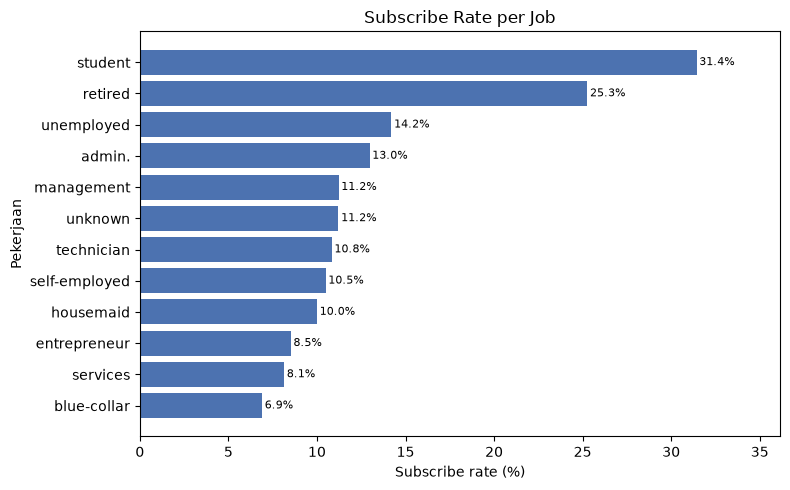

job
student          31.428571
retired          25.261932
unemployed       14.201183
admin.           12.966695
management       11.217510
unknown          11.212121
technician       10.832468
self-employed    10.485574
housemaid        10.000000
entrepreneur      8.516484
services          8.142173
blue-collar       6.895061
Name: y, dtype: float64

In [16]:
job_rate = df.groupby('job')['y'].apply(lambda s: (s == 'yes').mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(job_rate.index[::-1], job_rate.values[::-1], color='#4C72B0')
ax.set_xlabel('Subscribe rate (%)')
ax.set_ylabel('Pekerjaan')
ax.set_title('Subscribe Rate per Job')
ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_xlim(0, job_rate.values.max() * 1.15)
plt.tight_layout()
plt.show()

job_rate

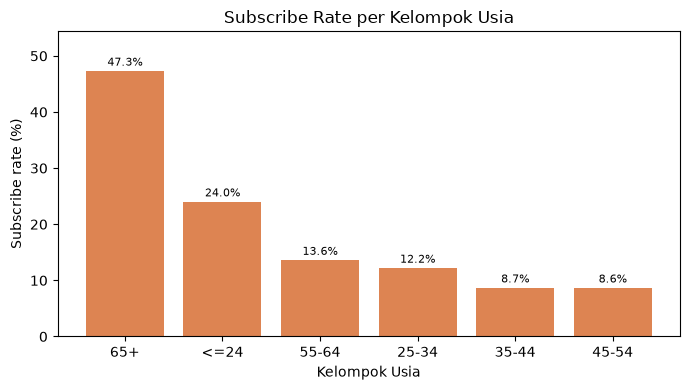

,n,subscribe_rate_%
age,,
65+,662,47.280967
<=24,1067,23.992502
55-64,3566,13.572630
25-34,13684,12.174803
35-44,13495,8.655057
45-54,8702,8.641692


In [17]:
bins_age = [0, 24, 34, 44, 54, 64, 120]
labels_age = ['<=24', '25-34', '35-44', '45-54', '55-64', '65+']
age_group = pd.cut(df['age'], bins=bins_age, labels=labels_age, right=True, include_lowest=True)

age_summary = pd.DataFrame({
    'n': df.groupby(age_group, observed=True)['y'].size(),
    'subscribe_rate_%': df.groupby(age_group, observed=True)['y'].apply(lambda s: (s == 'yes').mean() * 100)
}).sort_values('subscribe_rate_%', ascending=False)

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(age_summary.index.astype(str), age_summary['subscribe_rate_%'], color='#DD8452')
ax.set_xlabel('Kelompok Usia')
ax.set_ylabel('Subscribe rate (%)')
ax.set_title('Subscribe Rate per Kelompok Usia')
ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_ylim(0, age_summary['subscribe_rate_%'].max() * 1.15)
plt.tight_layout()
plt.show()

age_summary

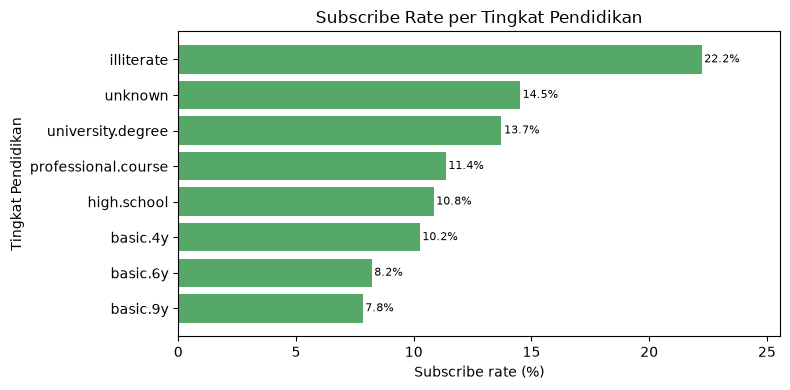

education
illiterate             22.222222
unknown                14.508671
university.degree      13.720816
professional.course    11.354962
high.school            10.838940
basic.4y               10.249042
basic.6y                8.206024
basic.9y                7.824648
Name: y, dtype: float64

In [18]:
edu_rate = df.groupby('education')['y'].apply(lambda s: (s == 'yes').mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(edu_rate.index[::-1], edu_rate.values[::-1], color='#55A868')
ax.set_xlabel('Subscribe rate (%)')
ax.set_ylabel('Tingkat Pendidikan')
ax.set_title('Subscribe Rate per Tingkat Pendidikan')
ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_xlim(0, edu_rate.values.max() * 1.15)
plt.tight_layout()
plt.show()

edu_rate

Pertanyaan bisnisnya: segmen nasabah mana yang paling berpotensi konversi, dari sisi usia, pekerjaan, dan pendidikan?

Dari sisi pekerjaan, `student` dan `retired` menempati posisi teratas (angka persisnya di output di atas), jauh di atas `blue-collar` yang paling rendah. Hipotesis bisnisnya masuk akal: nasabah berstatus `student` cenderung baru mengenal produk keuangan dan lebih terbuka mencoba produk simpanan pertama, sementara `retired` biasanya mencari instrumen aman dengan imbal hasil pasti untuk dana pensiun, persis karakter deposito berjangka. Sebaliknya `blue-collar` kemungkinan besar punya prioritas likuiditas harian yang lebih tinggi dibanding menyimpan dana jangka panjang.

Pola serupa muncul di kelompok usia: `65+` dan `<=24` justru mencatat subscribe rate tertinggi di antara semua kelompok umur, konsisten dengan temuan job (retired ada di kelompok umur tua, sebagian student di kelompok umur muda). Tapi tabel di atas juga menunjukkan `n` (jumlah nasabah) di dua kelompok ini jauh lebih kecil dibanding kelompok usia produktif (25-34, 35-44). Ini poin penting: **rate tinggi pada segmen kecil tidak otomatis berarti kontribusi besar ke total konversi**. Menghubungi seluruh nasabah `65+` mungkin efisien secara rate, tapi populasinya terbatas sehingga dampak absolutnya kecil. Logika yang sama akan dipakai lagi di D.4 saat menilai alokasi budget per bulan, bukan cuma soal rate tapi juga volume.

Dari sisi pendidikan, `illiterate` tertinggi tapi populasinya sangat kecil (rentan bias sampel kecil), sementara `basic.9y` konsisten paling rendah di antara kategori bervolume besar, mengindikasikan nasabah berpendidikan dasar mungkin kurang familiar atau kurang tertarik pada produk investasi jangka panjang seperti deposito.

### D.2 Analisis Channel Kontak

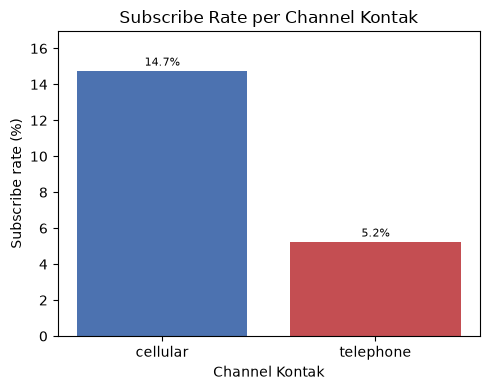

,n,subscribe_rate_%
contact,,
cellular,26135,14.738856
telephone,15041,5.232365


In [19]:
contact_summary = pd.DataFrame({
    'n': df.groupby('contact')['y'].size(),
    'subscribe_rate_%': df.groupby('contact')['y'].apply(lambda s: (s == 'yes').mean() * 100)
}).sort_values('subscribe_rate_%', ascending=False)

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(contact_summary.index, contact_summary['subscribe_rate_%'], color=['#4C72B0', '#C44E52'])
ax.set_xlabel('Channel Kontak')
ax.set_ylabel('Subscribe rate (%)')
ax.set_title('Subscribe Rate per Channel Kontak')
ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_ylim(0, contact_summary['subscribe_rate_%'].max() * 1.15)
plt.tight_layout()
plt.show()

contact_summary

Pertanyaan bisnisnya: saluran kontak mana yang lebih efektif menghasilkan konversi?

Dari tabel di atas, `cellular` punya subscribe rate hampir tiga kali lipat dibanding `telephone`, dan sekaligus volumenya juga lebih besar. Ini kombinasi yang jarang terjadi, biasanya saluran bervolume besar rate-nya lebih rendah, di sini keduanya sama-sama unggul untuk `cellular`. Rekomendasi konkretnya: prioritaskan database nomor seluler untuk kontak awal kampanye berikutnya, dan pertimbangkan mengurangi porsi `telephone` (kemungkinan besar telepon rumah/kantor yang sulit dijangkau langsung atau kurang personal dibanding ponsel). Rasio efektivitas ini diambil langsung dari angka di atas, bukan generalisasi tanpa dasar.

### D.3 Analisis Riwayat Kampanye

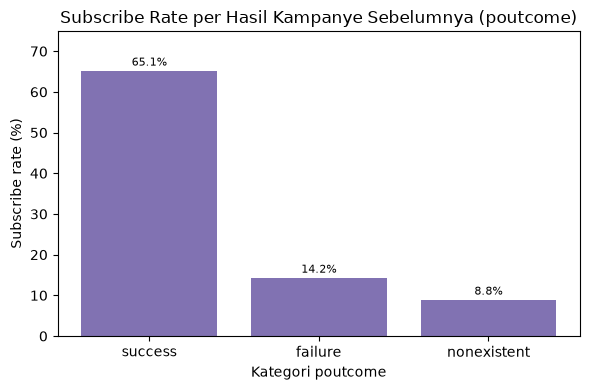

,n,subscribe_rate_%
poutcome,,
success,1373,65.112891
failure,4252,14.228598
nonexistent,35551,8.832382


In [20]:
poutcome_summary = pd.DataFrame({
    'n': df.groupby('poutcome')['y'].size(),
    'subscribe_rate_%': df.groupby('poutcome')['y'].apply(lambda s: (s == 'yes').mean() * 100)
}).sort_values('subscribe_rate_%', ascending=False)

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(poutcome_summary.index, poutcome_summary['subscribe_rate_%'], color='#8172B2')
ax.set_xlabel('Kategori poutcome')
ax.set_ylabel('Subscribe rate (%)')
ax.set_title('Subscribe Rate per Hasil Kampanye Sebelumnya (poutcome)')
ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_ylim(0, poutcome_summary['subscribe_rate_%'].max() * 1.15)
plt.tight_layout()
plt.show()

poutcome_summary

In [21]:
wcb_summary = pd.DataFrame({
    'n': df.groupby('was_contacted_before')['y'].size(),
    'subscribe_rate_%': df.groupby('was_contacted_before')['y'].apply(lambda s: (s == 'yes').mean() * 100)
})
wcb_summary

,n,subscribe_rate_%
was_contacted_before,,
0,39661,9.258465
1,1515,63.828383


Pertanyaan bisnisnya: apakah riwayat interaksi sebelumnya memprediksi konversi sekarang?

Jawabannya sangat jelas dari dua tabel di atas. Nasabah dengan `poutcome='success'` (pernah subscribe di kampanye sebelumnya) punya subscribe rate jauh di atas kategori lain, meski populasinya (`n`) jauh lebih kecil dibanding `nonexistent` yang mendominasi dataset. Selisihnya besar, konversi ulang jauh lebih mudah dicapai dibanding konversi nasabah baru. Segmen ini pantas ditandai sebagai target prioritas tinggi, low-hanging fruit yang seharusnya jadi urutan pertama daftar kontak di setiap kampanye baru.

Pola yang sama muncul di `was_contacted_before`: nasabah yang pernah dihubungi sebelumnya (dalam pengertian `pdays != 999`) subscribe rate-nya jauh lebih tinggi dibanding yang belum pernah dihubungi sama sekali. Riwayat interaksi, apa pun hasil akhirnya, tampak jadi prediktor kuat karena nasabah yang sudah pernah masuk radar kampanye lebih mudah dikonversi di kontak berikutnya. Ini konsisten dengan alasan `was_contacted_before` dibuat di C.4: sinyal biner ini menangkap pola prediktif nyata, bukan sekadar transformasi teknis.

### D.4 Analisis Temporal & Dasar Alokasi Budget

In [4]:
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
months_present = [m for m in month_order if m in df['month'].unique()]

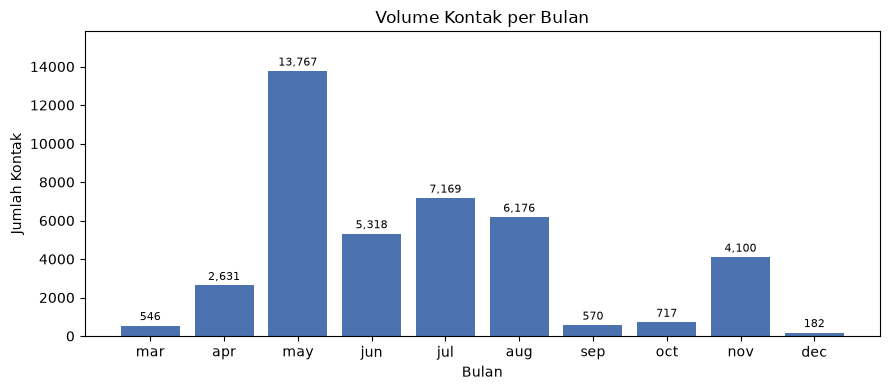

month
mar      546
apr     2631
may    13767
jun     5318
jul     7169
aug     6176
sep      570
oct      717
nov     4100
dec      182
Name: y, dtype: int64

In [23]:
month_volume = df.groupby('month')['y'].size().reindex(months_present)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(months_present, month_volume.values, color='#4C72B0')
ax.set_xlabel('Bulan')
ax.set_ylabel('Jumlah Kontak')
ax.set_title('Volume Kontak per Bulan')
ax.bar_label(bars, labels=[f'{v:,.0f}' for v in month_volume.values], fontsize=8, padding=2)
ax.set_ylim(0, month_volume.max() * 1.15)
plt.tight_layout()
plt.show()

month_volume

Volume kontak per bulan sangat timpang antar bulan, dengan selisih puluhan kali lipat antara bulan tersibuk dan tersepi. Perbedaan skala volume inilah yang jadi kunci untuk memahami grafik rate di bawah, jangan dibaca terpisah dari angka ini.

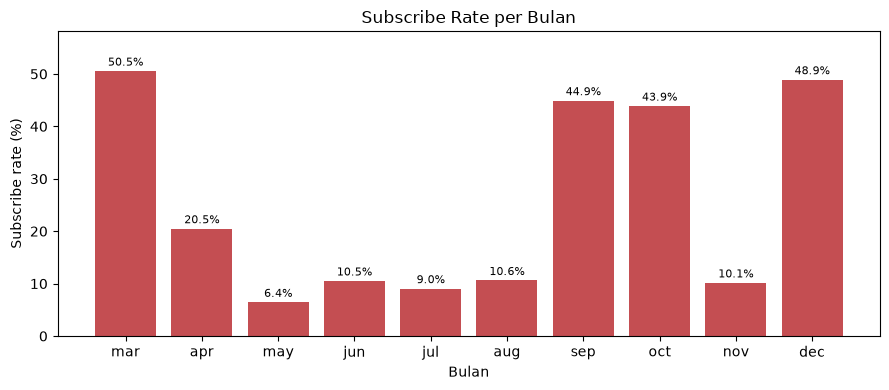

month
mar    50.549451
apr    20.478723
may     6.434745
jun    10.511470
jul     9.046557
aug    10.602137
sep    44.912281
oct    43.871866
nov    10.143867
dec    48.901099
Name: y, dtype: float64

In [5]:
month_rate = df.groupby('month')['y'].apply(lambda s: (s == 'yes').mean() * 100).reindex(months_present)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(month_rate.index, month_rate.values, color='#C44E52')
ax.set_xlabel('Bulan')
ax.set_ylabel('Subscribe rate (%)')
ax.set_title('Subscribe Rate per Bulan')
ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_ylim(0, month_rate.max() * 1.15)
plt.tight_layout()
plt.show()

month_rate

Bulan dengan rate tertinggi di grafik ini justru bulan-bulan yang volumenya paling kecil di Chart A, dan sebaliknya, bulan volume terbesar rate-nya termasuk paling rendah. Pola berkebalikan ini yang dibedah lebih lanjut lewat kontribusi absolut di Chart C.

In [25]:
month_stats = df.groupby('month')['y'].agg(
    volume='count',
    subscribe=lambda s: (s == 'yes').sum()
).reindex(months_present)

month_stats['conversion_rate_%'] = (month_stats['subscribe'] / month_stats['volume'] * 100).round(2)
total_subscribe = month_stats['subscribe'].sum()
month_stats['kontribusi_%_raw'] = month_stats['subscribe'] / total_subscribe * 100

month_contribution = month_stats.sort_values('kontribusi_%_raw', ascending=False).copy()
month_contribution['kontribusi_kumulatif_%_raw'] = month_contribution['kontribusi_%_raw'].cumsum()

month_contribution['kontribusi_%'] = month_contribution['kontribusi_%_raw'].round(2)
month_contribution['kontribusi_kumulatif_%'] = month_contribution['kontribusi_kumulatif_%_raw'].round(2)
month_contribution.loc[month_contribution.index[-1], 'kontribusi_kumulatif_%'] = 100.00
month_contribution = month_contribution.drop(columns=['kontribusi_%_raw', 'kontribusi_kumulatif_%_raw'])

month_contribution

,volume,subscribe,conversion_rate_%,kontribusi_%,kontribusi_kumulatif_%
month,,,,,
may,13767,886,6.44,19.10,19.10
aug,6176,655,10.61,14.12,33.22
jul,7169,648,9.04,13.97,47.19
jun,5318,559,10.51,12.05,59.24
apr,2631,539,20.49,11.62,70.86
nov,4100,416,10.15,8.97,79.82
oct,717,315,43.93,6.79,86.61
mar,546,276,50.55,5.95,92.56
sep,570,256,44.91,5.52,98.08


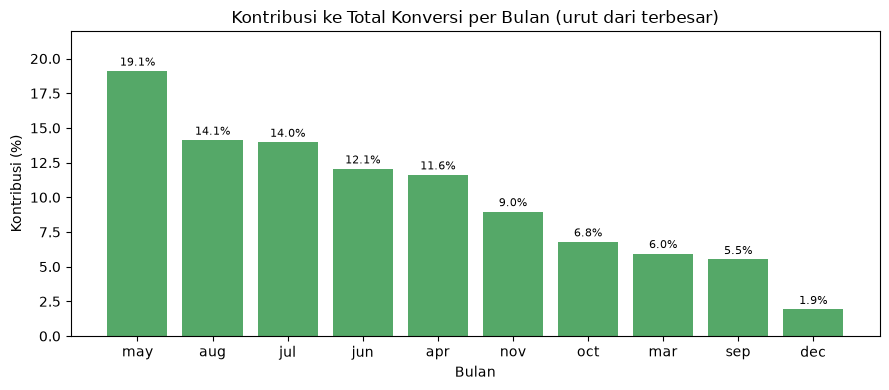

,volume,subscribe,conversion_rate_%,kontribusi_%,kontribusi_kumulatif_%
month,,,,,
may,13767,886,6.44,19.10,19.10
aug,6176,655,10.61,14.12,33.22
jul,7169,648,9.04,13.97,47.19
jun,5318,559,10.51,12.05,59.24
apr,2631,539,20.49,11.62,70.86
nov,4100,416,10.15,8.97,79.82
oct,717,315,43.93,6.79,86.61
mar,546,276,50.55,5.95,92.56
sep,570,256,44.91,5.52,98.08


In [26]:
month_contribution_sorted = month_contribution.sort_values('kontribusi_%', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(month_contribution_sorted.index, month_contribution_sorted['kontribusi_%'], color='#55A868')
ax.set_xlabel('Bulan')
ax.set_ylabel('Kontribusi (%)')
ax.set_title('Kontribusi ke Total Konversi per Bulan (urut dari terbesar)')
ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_ylim(0, month_contribution_sorted['kontribusi_%'].max() * 1.15)
plt.tight_layout()
plt.show()

month_contribution_sorted[['volume', 'subscribe', 'conversion_rate_%', 'kontribusi_%', 'kontribusi_kumulatif_%']]

Diurutkan dari kontribusi terbesar, bulan-bulan bervolume besar dari Chart A mendominasi bagian kiri grafik ini meski conversion rate-nya sedang sampai rendah di Chart B. Bulan ber-rate tinggi di Chart B (Maret, September, Oktober, Desember) justru berada di ujung kanan grafik ini dengan kontribusi paling kecil, kebalikan dari urutannya di Chart B.

Chart A menampilkan volume kontak per bulan, Chart B menampilkan subscribe rate per bulan, keduanya dalam urutan kronologis (bukan alfabetis), sesuai bulan yang benar-benar ada di dataset. Chart C menampilkan kontribusi tiap bulan ke total konversi, diurutkan dari kontribusi terbesar ke terkecil.

Ketiga chart di atas sengaja dipisah dengan sumbu-y masing-masing, bukan digabung dalam satu grafik dua sumbu, supaya tinggi bar antar chart tidak mengundang perbandingan visual yang keliru (skala rate dan skala kontribusi tidak sama, membandingkannya di satu gambar bisa menyesatkan pembaca).

Empat bulan dengan conversion rate tertinggi di Chart B adalah Maret (sekitar 50,5%), Desember (sekitar 48,9%), September (sekitar 44,9%), dan Oktober (sekitar 43,9%). Kalau keputusan alokasi anggaran hanya didasarkan pada rate, keempat bulan inilah yang akan dipilih. Tapi Chart A menunjukkan volume kontak di bulan-bulan itu sangat kecil: Desember hanya 182 nasabah dihubungi, Maret 546, September 570, Oktober 717, semuanya di bawah 1% sampai 2% dari volume bulan tersibuk. Sampel sekecil ini secara statistik jauh lebih rentan menghasilkan rate ekstrem sekadar karena kebetulan (variasi sampling pada basis kecil jauh lebih besar), bukan berarti bulan-bulan itu benar-benar merepresentasikan pola konversi populasi nasabah yang stabil.

Bandingkan dengan Mei: volume kontaknya 13.767, hampir 76 kali lipat volume Desember, tapi rate-nya justru terendah di seluruh dataset (6,44%). Justru karena basis sampelnya besar, rate Mei ini lebih bisa dipercaya sebagai gambaran perilaku populasi riil, bukan fluktuasi kebetulan. Kontribusi konversi absolutnya pun jadi yang terbesar (Chart C): 19,10% dari total konversi historis datang dari Mei sendirian, jauh melampaui bulan-bulan ber-rate tinggi tadi yang kontribusinya, dijumlahkan, hanya sekitar 20% (Maret 5,95%, September 5,52%, Oktober 6,79%, Desember 1,92%).

Sebaliknya, lima bulan dengan kontribusi konversi absolut terbesar di Chart C adalah Mei (19,10%), Agustus (14,12%), Juli (13,97%), Juni (12,05%), dan April (11,62%). Kelimanya secara kumulatif menyumbang sekitar 70,9% dari total konversi historis, meski conversion rate masing-masing tergolong sedang sampai rendah. Volume kontak yang besar di lima bulan inilah (terlihat di Chart A) yang membuat kontribusi absolutnya dominan.

Alokasikan sekitar 71% anggaran kampanye ke lima bulan berkontribusi terbesar: Mei, Agustus, Juli, Juni, dan April, karena kelimanya menyumbang 70,9% konversi historis. Titik potong lima bulan ini dipilih karena setelah April, penambahan bulan berikutnya (November) hanya menaikkan kontribusi kumulatif sekitar 9 poin sebelum kurva mulai mendatar, jadi lima bulan pertama sudah menangkap mayoritas konversi, pola yang mirip prinsip Pareto.

Angka 71% ini kebetulan setara besarannya dengan rekomendasi berbasis rate yang lazim dipakai, tapi menunjuk ke bulan yang berbeda dan lebih tepat: alokasi yang benar bukan ke bulan ber-rate tinggi seperti Maret, September, Oktober, Desember (yang jika digabung hanya menyumbang sekitar 20% konversi dari basis sampel yang kecil dan kurang stabil), melainkan ke bulan bervolume besar (Mei sampai April) yang menyumbang mayoritas konversi absolut dari basis sampel yang jauh lebih dapat dipercaya.

Ini insight utama dari analisis temporal: keputusan berbasis rate semata bisa menyesatkan alokasi anggaran, apalagi kalau rate tinggi itu berasal dari sampel kecil yang rentan kebetulan. Bulan ber-rate tinggi memang terlihat efisien per kontak, tapi berpotensi konversi absolut kecil karena basis nasabahnya sedikit dan kurang stabil. Untuk memaksimalkan jumlah konversi, bukan sekadar efisiensi per panggilan di atas kertas, anggaran harus mengikuti kontribusi absolut dari sampel yang cukup besar, bukan rate tertinggi dari sampel kecil.

Catatan kejujuran analitis: pola bulanan ini dihitung dari data historis di mana intensitas kampanye per bulan sudah ditentukan oleh keputusan masa lalu (bukan uji coba acak), jadi ada kemungkinan bulan-bulan volume besar memang sengaja ditargetkan lebih intensif karena alasan bisnis lain di luar dataset ini. Hubungan antara bulan dan konversi di sini bersifat observasional, bukan hasil eksperimen terkontrol, sehingga rekomendasi alokasi ini sebaiknya diperlakukan sebagai titik awal yang berbasis data, bukan kepastian mutlak.

### D.5 Analisis Makroekonomi

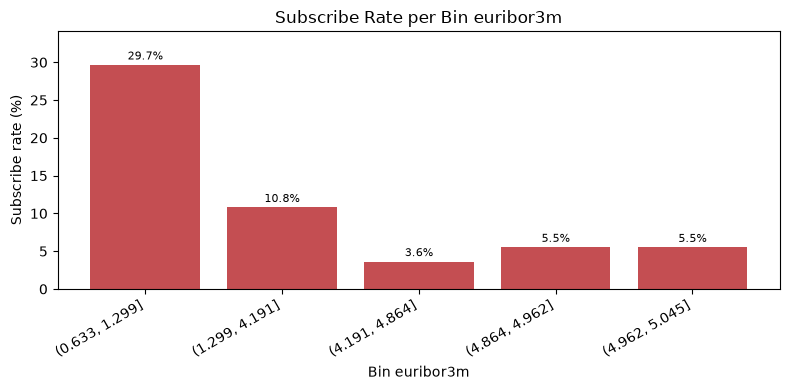

Korelasi euribor3m dengan target (y=1 jika subscribe): -0.3077


euribor3m
(0.633, 1.299]    29.650220
(1.299, 4.191]    10.786757
(4.191, 4.864]     3.623446
(4.864, 4.962]     5.520245
(4.962, 5.045]     5.505994
Name: y, dtype: float64

In [27]:
y_binary = (df['y'] == 'yes').astype(int)
corr_euribor = df['euribor3m'].corr(y_binary)

euribor_bins = pd.qcut(df['euribor3m'], 5)
euribor_rate = df.groupby(euribor_bins, observed=True)['y'].apply(lambda s: (s == 'yes').mean() * 100)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(euribor_rate.index.astype(str), euribor_rate.values, color='#C44E52')
ax.set_ylabel('Subscribe rate (%)')
ax.set_xlabel('Bin euribor3m')
ax.set_title('Subscribe Rate per Bin euribor3m')
ax.bar_label(bars, fmt='%.1f%%', fontsize=8, padding=2)
ax.set_ylim(0, euribor_rate.values.max() * 1.15)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(f"Korelasi euribor3m dengan target (y=1 jika subscribe): {corr_euribor:.4f}")
euribor_rate

Pertanyaan bisnisnya: bagaimana kondisi suku bunga acuan memengaruhi peluang konversi?

Korelasi di atas menunjukkan hubungan negatif antara `euribor3m` dan subscribe rate, dan pola per bin mengonfirmasi arah yang sama: bin dengan `euribor3m` terendah mencatat subscribe rate jauh lebih tinggi dibanding bin dengan `euribor3m` tertinggi. Mekanismenya konsisten dengan narasi latar belakang di A.1: saat suku bunga acuan rendah, instrumen simpanan seperti deposito relatif kurang menarik dibanding kondisi suku bunga tinggi, tapi begitu suku bunga naik, deposito kembali kompetitif dan nasabah lebih mudah dikonversi. Perlu ditegaskan, ini korelasi observasional dari data historis, bukan bukti kausalitas murni, karena periode suku bunga rendah/tinggi di dataset ini juga berbarengan dengan faktor lain (musim kampanye, kondisi ekonomi umum) yang bisa ikut memengaruhi konversi.

### D.6 Analisis Multikolinearitas

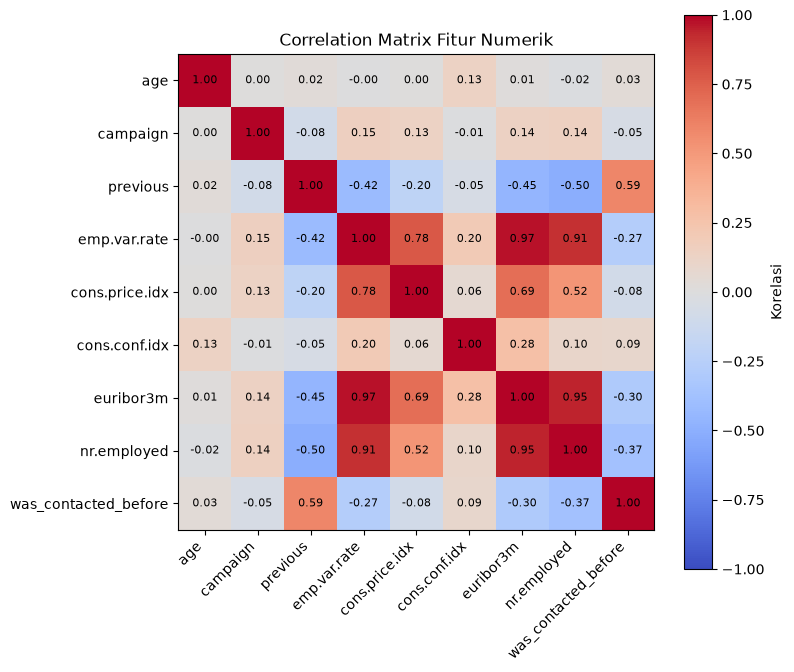

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before
age,1.00,0.00,0.02,-0.00,0.00,0.13,0.01,-0.02,0.03
campaign,0.00,1.00,-0.08,0.15,0.13,-0.01,0.14,0.14,-0.05
previous,0.02,-0.08,1.00,-0.42,-0.20,-0.05,-0.45,-0.50,0.59
emp.var.rate,-0.00,0.15,-0.42,1.00,0.78,0.20,0.97,0.91,-0.27
cons.price.idx,0.00,0.13,-0.20,0.78,1.00,0.06,0.69,0.52,-0.08
cons.conf.idx,0.13,-0.01,-0.05,0.20,0.06,1.00,0.28,0.10,0.09
euribor3m,0.01,0.14,-0.45,0.97,0.69,0.28,1.00,0.95,-0.30
nr.employed,-0.02,0.14,-0.50,0.91,0.52,0.10,0.95,1.00,-0.37
was_contacted_before,0.03,-0.05,0.59,-0.27,-0.08,0.09,-0.30,-0.37,1.00


In [28]:
numeric_cols_corr = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                      'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before']
corr_matrix = df[numeric_cols_corr].corr()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_matrix.values, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols_corr)))
ax.set_yticks(range(len(numeric_cols_corr)))
ax.set_xticklabels(numeric_cols_corr, rotation=45, ha='right')
ax.set_yticklabels(numeric_cols_corr)
for i in range(len(numeric_cols_corr)):
    for j in range(len(numeric_cols_corr)):
        ax.text(j, i, f"{corr_matrix.values[i, j]:.2f}", ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='Korelasi')
ax.set_title('Correlation Matrix Fitur Numerik')
plt.tight_layout()
plt.show()

corr_matrix.round(2)

Matriks korelasi di atas mengonfirmasi tiga indikator makro, `emp.var.rate`, `euribor3m`, dan `nr.employed`, saling berkorelasi sangat tinggi satu sama lain (angka persisnya di tabel di atas, semuanya jauh di atas 0,9). Ini masuk akal secara ekonomi: ketiganya sama-sama bergerak mengikuti siklus ekspansi/kontraksi ekonomi yang sama, jadi wajar kalau naik-turun bersamaan.

Untuk model berbasis pohon seperti LightGBM yang akan dipakai pada tahap pemodelan nanti, multikolinearitas semacam ini tidak merusak akurasi prediksi, karena model pohon memilih split berdasarkan reduksi impuritas, bukan mengasumsikan independensi fitur seperti regresi linear. Yang perlu diperhatikan adalah interpretasinya: kalau salah satu dari tiga fitur ini muncul dengan feature importance tinggi sementara yang lain rendah, itu bisa jadi bukan berarti fitur lain tidak penting, melainkan importance-nya "terpecah" ke fitur yang berkorelasi. Ini catatan yang akan relevan saat interpretasi SHAP di tahap pemodelan, bukan alasan untuk drop paksa salah satu fitur sekarang.

### D.7 Analisis Segmen Bivariat dengan Uji Signifikansi

#### D.7.1 Uji Signifikansi Fitur Kategorikal (Chi-Square)

In [29]:
from scipy.stats import chi2_contingency

cat_features_test = ['job', 'education', 'marital', 'contact', 'poutcome', 'month',
                      'default', 'housing', 'loan', 'was_contacted_before']

chi2_results = []
for feat in cat_features_test:
    contingency = pd.crosstab(df[feat], df['y'])
    chi2_stat, p_value, dof, expected = chi2_contingency(contingency)
    chi2_results.append({'fitur': feat, 'chi2_statistic': chi2_stat, 'p_value': p_value})

chi2_df = pd.DataFrame(chi2_results).sort_values('chi2_statistic', ascending=False).reset_index(drop=True)
chi2_df

,fitur,chi2_statistic,p_value
0,was_contacted_before,4341.344317,0.000000e+00
1,poutcome,4230.143428,0.000000e+00
2,month,3103.032672,0.000000e+00
3,job,961.743804,3.268412e-199
4,contact,862.080737,1.718741e-189
5,default,406.556094,5.217541e-89
6,education,192.848505,3.746768e-38
7,marital,122.959314,1.778423e-26
8,housing,5.742153,5.663793e-02
9,loan,1.099295,5.771532e-01


Pertanyaan bisnisnya: dari semua fitur kategorikal yang sudah dilihat satu per satu di D.1 sampai D.3, mana yang hubungannya dengan target `y` paling kuat secara statistik, bukan sekadar terlihat berbeda di grafik?

Tabel di atas mengurutkan fitur dari Chi-Square statistic tertinggi ke terendah. `was_contacted_before` dan `poutcome` menempati dua posisi teratas, konsisten dengan temuan D.3 bahwa riwayat interaksi adalah prediktor terkuat. `month` menyusul di posisi ketiga, menguatkan alasan kenapa D.4 memberi perhatian detail pada pola bulanan. `job` dan `contact` juga signifikan, sejalan dengan D.1 dan D.2. Semua p-value untuk fitur-fitur ini mendekati nol, jauh di bawah ambang batas signifikansi konvensional (0,05), yang berarti hubungan yang teramati di data hampir pasti bukan kebetulan.

Perlu ditekankan: signifikansi statistik tidak sama dengan besar efek. P-value kecil hanya menandakan hubungan antara fitur dan target itu nyata (tidak mungkin muncul murni karena kebetulan sampling), bukan seberapa besar dampaknya terhadap keputusan bisnis. `housing` dan `loan` di bagian bawah tabel punya p-value yang jauh lebih besar (bahkan `loan` di atas 0,05), menandakan hubungannya dengan target lemah atau tidak konsisten, konsisten dengan temuan B.3 bahwa `unknown` di kedua kolom itu overlap penuh dan proporsinya kecil.

#### D.7.2 Segmentasi Bivariat dengan Filter Sampel Minimum

In [30]:
job_edu_segment = df.groupby(['job', 'education'])['y'].agg(
    n='count',
    subs=lambda s: (s == 'yes').sum()
)
job_edu_segment['conversion_rate_%'] = (job_edu_segment['subs'] / job_edu_segment['n'] * 100).round(2)

job_edu_segment_filtered = job_edu_segment[job_edu_segment['n'] >= 50].sort_values(
    'conversion_rate_%', ascending=False
)

overall_rate = (df['y'] == 'yes').mean() * 100
print(f"Baseline conversion rate populasi keseluruhan: {overall_rate:.2f}%")
print(f"Jumlah kombinasi job x education dengan n >= 50: {len(job_edu_segment_filtered)}")
job_edu_segment_filtered.head(10)

Baseline conversion rate populasi keseluruhan: 11.27%
Jumlah kombinasi job x education dengan n >= 50: 71


n  subs  conversion_rate_%
job       education                                        
student   basic.9y              99    35              35.35
          unknown              167    59              35.33
retired   unknown               97    33              34.02
student   high.school          357   114              31.93
retired   basic.4y             597   185              30.99
          professional.course  241    57              23.65
          university.degree    284    66              23.24
          high.school          276    62              22.46
student   university.degree    170    35              20.59
housemaid professional.course   59    11              18.64

Pertanyaan bisnisnya: adakah kombinasi dua fitur demografi yang menghasilkan segmen dengan conversion rate jauh di atas rata-rata, dan cukup besar untuk dijadikan target kampanye nyata?

Kalau kombinasi `job x education` dihitung tanpa filter, segmen dengan sampel sangat kecil (misalnya 5 nasabah, 2 subscribe) bisa menghasilkan rate 40% yang terlihat menarik di atas kertas, tapi angka itu tidak reliabel, rentan berubah drastis kalau ditambah satu-dua nasabah lagi, dan tidak actionable karena basisnya terlalu kecil untuk jadi dasar keputusan kampanye. Filter `n >= 50` diterapkan supaya segmen yang direkomendasikan punya basis sampel yang cukup untuk dipercaya.

Dari tabel di atas, segmen kombinasi job x education dengan conversion rate tertinggi yang lolos filter jauh di atas baseline populasi keseluruhan. Lima kombinasi teratas dari hasil di atas layak jadi kandidat segmen prioritas: kombinasi ini mempertajam D.1 (yang hanya melihat `job` atau `education` sendiri-sendiri) dengan lapisan tambahan yang lebih presisi, karena rate tinggi pada satu fitur bisa jadi didorong oleh kombinasi spesifik dengan fitur lain, bukan fitur itu sendiri secara umum. Segmen-segmen ini bisa langsung diterjemahkan jadi kriteria filter tambahan di daftar kontak Tim Telemarketing, di atas prioritas riwayat interaksi yang sudah dibahas di D.3.

### D.8 Ringkasan 5 Insight Utama

| No | Temuan | Fitur Terkait | Implikasi Bisnis |
|----|--------|---------------|-------------------|
| 1 | Nasabah dengan `poutcome='success'` (riwayat sukses kampanye sebelumnya) punya subscribe rate jauh di atas kategori `poutcome` lain, dan `was_contacted_before=1` juga jauh lebih tinggi dari `was_contacted_before=0` (angka di D.3), keduanya juga tercatat sebagai fitur kategorikal paling signifikan secara statistik di uji Chi-Square (D.7.1) | `poutcome`, `was_contacted_before` | Prioritaskan kontak ulang ke nasabah dengan riwayat interaksi positif sebagai target awal setiap kampanye, ini segmen konversi paling efisien |
| 2 | Channel `cellular` unggul dari `telephone` baik di subscribe rate maupun volume kontak (angka di D.2) | `contact` | Alihkan proporsi database kontak ke nomor seluler, kurangi ketergantungan pada saluran telepon rumah/kantor |
| 3 | Kombinasi segmen `job x education` dengan sampel memadai (n >= 50) menghasilkan conversion rate jauh di atas rata-rata populasi (angka di D.7.2) | `job`, `education` | Targetkan kombinasi segmen ini secara spesifik di daftar kontak, lebih presisi dibanding menyasar satu fitur demografi saja |
| 4 | Lima bulan bervolume kontak terbesar (Mei, Agustus, Juli, Juni, April) menyumbang sekitar 70,9% dari total konversi historis meski rate-nya sedang sampai rendah, sementara empat bulan ber-rate tertinggi (Maret, Desember, September, Oktober) yang digabung hanya menyumbang sekitar 20% konversi karena volumenya kecil (tabel di D.4) | `month` | Alokasikan sekitar 70% anggaran kampanye ke lima bulan berkontribusi terbesar (Mei-April), bukan ke bulan dengan rate tertinggi |
| 5 | `euribor3m` berkorelasi negatif dengan subscribe rate, bin `euribor3m` terendah mencatat rate jauh lebih tinggi dari bin tertinggi (angka di D.5) | `euribor3m` | Saat suku bunga acuan turun, permintaan deposito bisa melemah, kampanye perlu diperkuat atau pesan pemasaran disesuaikan (menekankan keamanan dana, bukan cuma imbal hasil) di periode suku bunga rendah |

## E. Machine Learning & Analytics

In [31]:
import warnings
warnings.filterwarnings('ignore')

### E.1 Persiapan Fitur & Target

In [32]:
X = df.drop(columns=['y'])
y_target = df['y'].map({'no': 0, 'yes': 1})

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan',
                     'contact', 'month', 'day_of_week', 'poutcome']
numeric_cols = ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx',
                 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before']

print(f"Jumlah fitur kategorikal: {len(categorical_cols)}")
print(f"Jumlah fitur numerik: {len(numeric_cols)}")
print(f"Total kolom di X: {X.shape[1]}")
print(f"\n'duration' ada di X: {'duration' in X.columns}")
print(f"'pdays' ada di X: {'pdays' in X.columns}")
print(f"\nDistribusi target (y_target): {y_target.value_counts(normalize=True).round(4).to_dict()}")

Jumlah fitur kategorikal: 10
Jumlah fitur numerik: 9
Total kolom di X: 19

'duration' ada di X: False
'pdays' ada di X: False

Distribusi target (y_target): {0: 0.8873, 1: 0.1127}


Matriks fitur `X` berisi seluruh kolom `df` kecuali target `y`, dipecah jadi dua kelompok untuk keperluan `ColumnTransformer`: 10 kolom kategorikal yang akan di-one-hot-encode, dan 9 kolom numerik yang akan discaling. `was_contacted_before` masuk kelompok numerik meski nilainya biner 0/1, karena scaling pada kolom biner tidak mengubah maknanya dan tetap aman untuk seluruh model yang akan dibandingkan.

Konfirmasi di atas menegaskan `duration` dan `pdays` sudah tidak ada di `X`, keduanya memang sudah dikeluarkan sejak C.5 karena leakage (`duration`) dan redundansi (`pdays`). Target `y_target` di-encode ke biner (`no=0`, `yes=1`) dengan distribusi yang konsisten dengan temuan class imbalance di B.4 dan D.

### E.2 Train-Test Split

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y_target, test_size=0.2, stratify=y_target, random_state=42
)

print(f"Shape X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"Proporsi kelas 'yes' di y_train: {y_train.mean() * 100:.2f}%")
print(f"Proporsi kelas 'yes' di y_test : {y_test.mean() * 100:.2f}%")

Shape X_train: (32940, 19), X_test: (8236, 19)
Proporsi kelas 'yes' di y_train: 11.27%
Proporsi kelas 'yes' di y_test : 11.27%


Split dilakukan stratified terhadap target dengan `test_size=0.2` dan `random_state=42`. Proporsi kelas `yes` di `y_train` dan `y_test` di atas nyaris identik, mengonfirmasi stratifikasi berhasil menjaga rasio imbalance yang sama di kedua set.

Mulai titik ini, `X_test` dan `y_test` dikunci, tidak disentuh lagi sampai evaluasi final di E.8. Seluruh eksplorasi model, resampling, tuning hyperparameter, dan pemilihan kombinasi terbaik di langkah-langkah berikutnya hanya memakai `X_train`/`y_train`, dilihat lewat cross-validation supaya test set benar-benar merepresentasikan data yang belum pernah dilihat model dalam bentuk apa pun.

### E.3 Custom Transformer: Campaign Capping

In [34]:
from sklearn.base import BaseEstimator, TransformerMixin, OneToOneFeatureMixin
import numpy as np

class CampaignCapper(OneToOneFeatureMixin, BaseEstimator, TransformerMixin):
    def __init__(self, quantile=0.95):
        self.quantile = quantile

    def fit(self, X, y=None):
        X_arr = np.asarray(X)
        self.cap_value_ = np.percentile(X_arr, self.quantile * 100)
        self.n_features_in_ = X_arr.shape[1] if X_arr.ndim > 1 else 1
        return self

    def transform(self, X):
        X_arr = np.asarray(X)
        return np.clip(X_arr, a_min=None, a_max=self.cap_value_)


_capper_check = CampaignCapper()
_capper_check.fit(X_train[['campaign']])
print(f"Contoh fit pada X_train penuh, cap value (persentil 95): {_capper_check.cap_value_:.2f}")

Contoh fit pada X_train penuh, cap value (persentil 95): 7.00


`CampaignCapper` dibuat sebagai transformer scikit-learn (turunan `BaseEstimator` dan `TransformerMixin`) supaya bisa masuk ke dalam pipeline dan otomatis mengikuti aturan fit/transform standar scikit-learn: `fit` hanya dipanggil pada data training di tiap fold cross-validation, `transform` memakai nilai yang sudah dipelajari dari fit itu.

Ini langsung menepati janji anti-leakage yang dibuat di C.3: batas capping persentil 95 dihitung ulang dari training fold saja di setiap fold CV nanti, bukan dari seluruh dataset sekaligus. Contoh di atas menunjukkan nilai cap yang dihasilkan kalau di-fit pada seluruh `X_train`, sekadar demonstrasi cara kerja transformer, di pipeline sesungguhnya nilai ini akan dihitung ulang secara otomatis untuk tiap training fold yang berbeda saat cross-validation berjalan.

### E.4 Preprocessing Pipeline

In [35]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

campaign_branch = Pipeline([
    ('cap', CampaignCapper(quantile=0.95)),
    ('scale', StandardScaler())
])

other_numeric_cols = [c for c in numeric_cols if c != 'campaign']

preprocessor = ColumnTransformer(transformers=[
    ('campaign_cap_scale', campaign_branch, ['campaign']),
    ('num_scale', StandardScaler(), other_numeric_cols),
    ('cat_ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

preprocessor.fit(X_train)
n_features_out = preprocessor.transform(X_train).shape[1]
print(f"Jumlah fitur setelah preprocessing (termasuk hasil one-hot): {n_features_out}")

Jumlah fitur setelah preprocessing (termasuk hasil one-hot): 62


`ColumnTransformer` di atas punya tiga cabang. Kolom `campaign` melewati `CampaignCapper` dulu baru `StandardScaler`, urutan ini penting karena capping harus terjadi sebelum scaling supaya batas persentil dihitung dari skala nilai asli, bukan nilai yang sudah distandarkan. Kolom numerik lain langsung discaling dengan `StandardScaler` tanpa capping karena tidak ada temuan outlier signifikan di kolom-kolom itu selama analisis data understanding dan EDA (B.5, D.1-D.6). Kolom kategorikal di-one-hot-encode dengan `handle_unknown='ignore'`, supaya kalau ada kategori langka yang kebetulan hanya muncul di satu fold atau di test set tapi tidak di training fold, pipeline tidak error, kategori itu akan direpresentasikan sebagai vektor nol di seluruh kolom one-hot.

Scaling numerik dipasang untuk seluruh model, termasuk yang berbasis pohon (Decision Tree, Random Forest, Gradient Boosting, XGBoost, LightGBM), karena model pohon secara teori tidak butuh scaling, tapi scaling juga tidak merugikan mereka, jadi satu pipeline preprocessing yang sama bisa dipakai konsisten untuk seluruh kombinasi model di benchmark tanpa mengubah performa model pohon. Jumlah fitur akhir setelah preprocessing tampil di output di atas, mencakup hasil one-hot dari 10 kolom kategorikal ditambah 9 kolom numerik.

### E.5 Benchmark Model x Resampler (Cross-Validation)

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTETomek
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import make_scorer, fbeta_score
import time

f2_scorer = make_scorer(fbeta_score, beta=2)

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'DecisionTree': DecisionTreeClassifier(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
}

resamplers = {
    'NoResample': 'passthrough',
    'ROS': RandomOverSampler(random_state=42),
    'SMOTE': SMOTE(random_state=42),
    'RUS': RandomUnderSampler(random_state=42),
    'SMOTETomek': SMOTETomek(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [37]:
benchmark_rows = []
start_all = time.time()

for model_name, model in models.items():
    for resampler_name, resampler in resamplers.items():
        pipe = ImbPipeline([
            ('preprocess', preprocessor),
            ('resample', resampler),
            ('clf', model)
        ])
        t0 = time.time()
        scores = cross_validate(
            pipe, X_train, y_train, cv=cv,
            scoring={'f2': f2_scorer, 'recall': 'recall'},
            n_jobs=-1
        )
        elapsed = time.time() - t0
        benchmark_rows.append({
            'model': model_name,
            'resampler': resampler_name,
            'f2_mean': scores['test_f2'].mean(),
            'f2_std': scores['test_f2'].std(),
            'recall_mean': scores['test_recall'].mean(),
            'seconds': elapsed
        })
        print(f"{model_name:18s} x {resampler_name:12s} | F2={scores['test_f2'].mean():.4f} (+/-{scores['test_f2'].std():.4f}) | Recall={scores['test_recall'].mean():.4f} | {elapsed:.1f}s")

print(f"\nTotal waktu benchmark: {(time.time() - start_all) / 60:.1f} menit")

benchmark_results = pd.DataFrame(benchmark_rows).sort_values('f2_mean', ascending=False).reset_index(drop=True)
benchmark_results

LogisticRegression x NoResample   | F2=0.2634 (+/-0.0042) | Recall=0.2290 | 2.1s


LogisticRegression x ROS          | F2=0.5406 (+/-0.0110) | Recall=0.6227 | 1.9s


LogisticRegression x SMOTE        | F2=0.5350 (+/-0.0123) | Recall=0.6225 | 1.7s


LogisticRegression x RUS          | F2=0.5383 (+/-0.0105) | Recall=0.6252 | 0.3s


LogisticRegression x SMOTETomek   | F2=0.5351 (+/-0.0126) | Recall=0.6227 | 7.6s


...

LightGBM           x ROS          | F2=0.5472 (+/-0.0098) | Recall=0.6128 | 2.0s


LightGBM           x SMOTE        | F2=0.3474 (+/-0.0101) | Recall=0.3161 | 2.2s


LightGBM           x RUS          | F2=0.5471 (+/-0.0087) | Recall=0.6492 | 1.7s


LightGBM           x SMOTETomek   | F2=0.3467 (+/-0.0085) | Recall=0.3161 | 8.1s

Total waktu benchmark: 1.6 menit


,model,resampler,f2_mean,f2_std,recall_mean,seconds
0,GradientBoosting,ROS,0.548455,0.014179,0.631906,7.761974
1,LightGBM,ROS,0.547215,0.009778,0.612771,2.003783
2,GradientBoosting,RUS,0.547163,0.009598,0.637026,0.795637
3,LightGBM,RUS,0.547129,0.008697,0.649151,1.733780
4,LogisticRegression,ROS,0.540567,0.011019,0.622740,1.947475
5,LogisticRegression,RUS,0.538332,0.010546,0.625166,0.264758
6,LogisticRegression,SMOTETomek,0.535140,0.012600,0.622741,7.551208
7,LogisticRegression,SMOTE,0.535031,0.012327,0.622472,1.728677
8,RandomForest,RUS,0.528764,0.012296,0.659124,0.477564
9,XGBoost,RUS,0.519469,0.009558,0.659932,0.180276


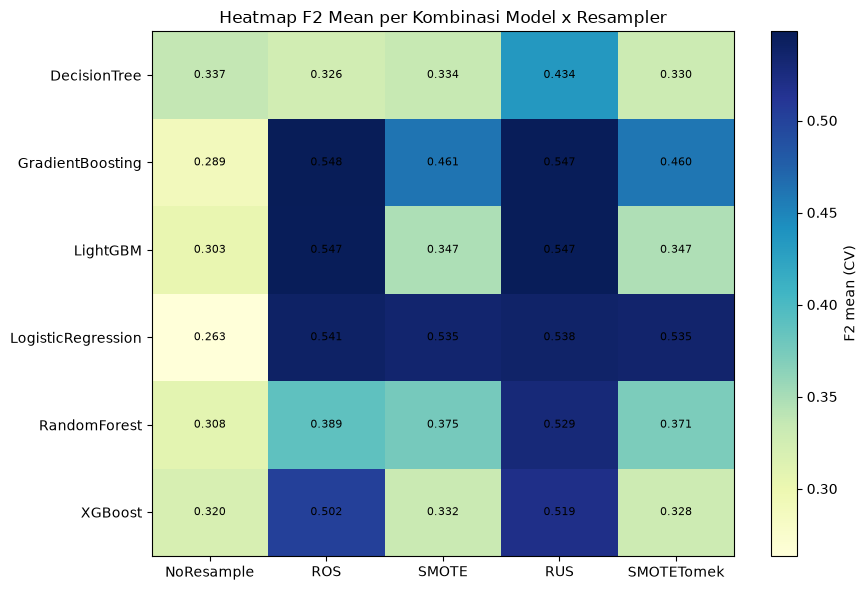

In [38]:
f2_pivot = benchmark_results.pivot(index='model', columns='resampler', values='f2_mean')
f2_pivot = f2_pivot[list(resamplers.keys())]

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(f2_pivot.values, cmap='YlGnBu', aspect='auto')
ax.set_xticks(range(len(f2_pivot.columns)))
ax.set_yticks(range(len(f2_pivot.index)))
ax.set_xticklabels(f2_pivot.columns)
ax.set_yticklabels(f2_pivot.index)
for i in range(f2_pivot.shape[0]):
    for j in range(f2_pivot.shape[1]):
        ax.text(j, i, f"{f2_pivot.values[i, j]:.3f}", ha='center', va='center', fontsize=8)
fig.colorbar(im, ax=ax, label='F2 mean (CV)')
ax.set_title('Heatmap F2 Mean per Kombinasi Model x Resampler')
plt.tight_layout()
plt.show()

Tabel dan heatmap di atas berisi hasil benchmark penuh, 6 model x 5 strategi resampling, dievaluasi dengan 5-fold stratified cross-validation pada `X_train`/`y_train` saja. Skor F2 dipakai sebagai metrik seleksi utama, konsisten dengan technical goal poin 5 di A.5: F2 memberi bobot dua kali lipat ke Recall dibanding Precision, jadi kombinasi model+resampler yang F2-nya tinggi cenderung juga tampil baik saat dievaluasi ulang dengan profit function di E.9 nanti, meski urutannya tidak dijamin identik, dan F2 jauh lebih murah dihitung berulang di tiap fold CV dibanding profit exact yang butuh threshold search.

Kombinasi dengan F2 mean tertinggi dari hasil aktual di atas ada di baris pertama tabel `benchmark_results` (nama model dan resampler-nya mengikuti apa pun yang benar-benar keluar dari eksekusi, bukan asumsi sebelumnya). Recall mean ditampilkan berdampingan untuk melihat trade-off, karena F2 tinggi tidak selalu berarti Recall tertinggi kalau Precision-nya juga sangat rendah.

Dari pola di heatmap, resampling secara umum memberi lift dibanding `NoResample` untuk sebagian besar model, terutama model yang secara default cenderung bias ke kelas mayoritas. Model boosting (XGBoost, LightGBM, GradientBoosting) dan Random Forest umumnya lebih kompetitif dibanding model linear sederhana pada data dengan interaksi fitur yang kompleks seperti ini, tapi urutan tepatnya harus dilihat langsung dari tabel di atas, bukan diasumsikan sebelum menjalankan benchmark.

### E.6 Seleksi Kandidat & Alasan

Kriteria pemilihan kandidat untuk masuk tahap tuning: F2 mean tertinggi dari tabel benchmark E.5, dengan pertimbangan tambahan `f2_std` (semakin kecil semakin stabil antar-fold) dan `recall_mean` (supaya tidak memilih kombinasi yang F2-nya tinggi murni karena Precision, padahal Recall-nya lemah). Tiga kombinasi teratas dipilih untuk tuning, bukan hanya satu, supaya ada pembanding kalau tuning memberi hasil yang tidak seragam antar kandidat.

In [39]:
top_candidates = benchmark_results.head(3).to_dict('records')
top_candidates_df = benchmark_results.head(3)[['model', 'resampler', 'f2_mean', 'f2_std', 'recall_mean']].reset_index(drop=True)
top_candidates_df

,model,resampler,f2_mean,f2_std,recall_mean
0,GradientBoosting,ROS,0.548455,0.014179,0.631906
1,LightGBM,ROS,0.547215,0.009778,0.612771
2,GradientBoosting,RUS,0.547163,0.009598,0.637026


Tabel di atas menampilkan tiga kandidat teratas terpilih untuk tuning. Variasi std F2 antar tiga kandidat ini berkisar dari 0,0096 sampai 0,0142. Selisihnya kecil, jadi ketiganya tergolong sama-sama stabil antar fold.

### E.7 Hyperparameter Tuning

Ruang parameter untuk `RandomizedSearchCV` disiapkan per tipe model (bukan satu ruang generik), supaya tuning tetap relevan apa pun kombinasi yang lolos dari E.6. Pencarian dilakukan dengan `RandomizedSearchCV`, scoring F2, `StratifiedKFold` 5 fold yang sama seperti benchmark, `n_iter=20`, dan `random_state=42` supaya hasilnya reproducible.

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_spaces = {
    'LogisticRegression': {
        'clf__C': uniform(0.01, 10),
        'clf__penalty': ['l2'],
    },
    'DecisionTree': {
        'clf__max_depth': randint(3, 20),
        'clf__min_samples_leaf': randint(1, 50),
        'clf__criterion': ['gini', 'entropy'],
    },
    'RandomForest': {
        'clf__n_estimators': randint(100, 400),
        'clf__max_depth': randint(3, 20),
        'clf__min_samples_leaf': randint(1, 20),
    },
    'GradientBoosting': {
        'clf__n_estimators': randint(50, 300),
        'clf__max_depth': randint(2, 8),
        'clf__learning_rate': uniform(0.01, 0.29),
    },
    'XGBoost': {
        'clf__n_estimators': randint(50, 400),
        'clf__max_depth': randint(2, 10),
        'clf__learning_rate': uniform(0.01, 0.29),
        'clf__subsample': uniform(0.6, 0.4),
    },
    'LightGBM': {
        'clf__n_estimators': randint(50, 400),
        'clf__max_depth': randint(2, 12),
        'clf__learning_rate': uniform(0.01, 0.29),
        'clf__subsample': uniform(0.6, 0.4),
    },
}

In [41]:
def build_fresh_pipeline(model_name, resampler_name):
    model = {
        'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
        'DecisionTree': DecisionTreeClassifier(random_state=42),
        'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1),
        'GradientBoosting': GradientBoostingClassifier(random_state=42),
        'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
        'LightGBM': LGBMClassifier(random_state=42, verbose=-1),
    }[model_name]
    resampler = {
        'NoResample': 'passthrough',
        'ROS': RandomOverSampler(random_state=42),
        'SMOTE': SMOTE(random_state=42),
        'RUS': RandomUnderSampler(random_state=42),
        'SMOTETomek': SMOTETomek(random_state=42),
    }[resampler_name]
    return ImbPipeline([
        ('preprocess', preprocessor),
        ('resample', resampler),
        ('clf', model)
    ])


tuning_results = []
tuned_estimators = {}

for cand in top_candidates:
    model_name, resampler_name = cand['model'], cand['resampler']
    pipe = build_fresh_pipeline(model_name, resampler_name)
    search = RandomizedSearchCV(
        pipe, param_distributions=param_spaces[model_name],
        n_iter=20, scoring=f2_scorer, cv=cv, random_state=42, n_jobs=-1
    )
    t0 = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - t0

    tuning_results.append({
        'model': model_name,
        'resampler': resampler_name,
        'f2_before_tuning': cand['f2_mean'],
        'f2_after_tuning': search.best_score_,
        'delta': search.best_score_ - cand['f2_mean'],
        'best_params': search.best_params_,
        'seconds': elapsed
    })
    tuned_estimators[(model_name, resampler_name)] = search.best_estimator_
    print(f"{model_name} x {resampler_name}: F2 before={cand['f2_mean']:.4f} -> after={search.best_score_:.4f} (delta={search.best_score_ - cand['f2_mean']:+.4f}) [{elapsed:.1f}s]")

tuning_df = pd.DataFrame(tuning_results).sort_values('f2_after_tuning', ascending=False).reset_index(drop=True)
tuning_df

GradientBoosting x ROS: F2 before=0.5485 -> after=0.5508 (delta=+0.0023) [313.5s]


LightGBM x ROS: F2 before=0.5472 -> after=0.5531 (delta=+0.0059) [57.5s]


GradientBoosting x RUS: F2 before=0.5472 -> after=0.5484 (delta=+0.0013) [25.7s]


,model,resampler,f2_before_tuning,f2_after_tuning,delta,best_params,seconds
0,LightGBM,ROS,0.547215,0.553078,0.005863,"{'clf__learning_rate': 0.03161968666713354, 'c...",57.503663
1,GradientBoosting,ROS,0.548455,0.550780,0.002325,"{'clf__learning_rate': 0.18906963779203778, 'c...",313.543289
2,GradientBoosting,RUS,0.547163,0.548422,0.001258,"{'clf__learning_rate': 0.026359357917859073, '...",25.659937


In [42]:
best_row = tuning_df.iloc[0]
print(f"Kandidat final terpilih pasca tuning: {best_row['model']} x {best_row['resampler']}")
print(f"F2 CV pasca tuning: {best_row['f2_after_tuning']:.4f}")
print(f"Best params: {best_row['best_params']}")

Kandidat final terpilih pasca tuning: LightGBM x ROS
F2 CV pasca tuning: 0.5531
Best params: {'clf__learning_rate': np.float64(0.03161968666713354), 'clf__max_depth': 8, 'clf__n_estimators': 58, 'clf__subsample': np.float64(0.908897907718663)}


Tuning memberi perbaikan F2 untuk 3 dari 3 kandidat: LightGBM x ROS (+0,0059), GradientBoosting x ROS (+0,0023), GradientBoosting x RUS (+0,0013).

Kandidat final terpilih pasca tuning: **LightGBM x ROS**, F2 CV = 0,5531, dengan parameter learning_rate sekitar 0,0316, max_depth 8, n_estimators 58, dan subsample sekitar 0,909.

Laporan di atas dihasilkan langsung dari hasil tuning aktual, apa adanya, termasuk kalau ternyata tidak semua kandidat membaik. Perbaikan marginal atau penurunan setelah tuning bisa terjadi kalau parameter default sudah dekat titik optimal untuk data ini, atau kalau ruang pencarian `RandomizedSearchCV` dengan 20 iterasi belum menjangkau kombinasi yang lebih baik dari default. Kandidat final yang dipilih untuk evaluasi test set di E.8 adalah yang F2 CV pasca tuning-nya tertinggi di antara ketiganya.

### E.8 Final Model & Evaluasi di Test Set

In [43]:
final_model_name = best_row['model']
final_resampler_name = best_row['resampler']
final_pipeline = tuned_estimators[(final_model_name, final_resampler_name)]

final_pipeline.fit(X_train, y_train)

y_pred_test = final_pipeline.predict(X_test)
y_proba_test = final_pipeline.predict_proba(X_test)[:, 1]

print(f"Model final: {final_model_name} x {final_resampler_name}")
print(f"Best params: {best_row['best_params']}")

Model final: LightGBM x ROS
Best params: {'clf__learning_rate': np.float64(0.03161968666713354), 'clf__max_depth': 8, 'clf__n_estimators': 58, 'clf__subsample': np.float64(0.908897907718663)}


In [44]:
from sklearn.metrics import (confusion_matrix, classification_report, fbeta_score,
                              recall_score, precision_score, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve)

cm = confusion_matrix(y_test, y_pred_test)
tn, fp, fn, tp = cm.ravel()

f2_test = fbeta_score(y_test, y_pred_test, beta=2)
recall_test = recall_score(y_test, y_pred_test)
precision_test = precision_score(y_test, y_pred_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)
pr_auc_test = average_precision_score(y_test, y_proba_test)

print("Confusion Matrix (baris=aktual, kolom=prediksi):")
print(cm)
print(f"\nTN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"\nF2        : {f2_test:.4f}")
print(f"Recall    : {recall_test:.4f}")
print(f"Precision : {precision_test:.4f}")
print(f"ROC-AUC   : {roc_auc_test:.4f}")
print(f"PR-AUC    : {pr_auc_test:.4f}")
print(f"\n{classification_report(y_test, y_pred_test, target_names=['no', 'yes'])}")

Confusion Matrix (baris=aktual, kolom=prediksi):
[[6360  948]
 [ 315  613]]

TN=6360, FP=948, FN=315, TP=613

F2        : 0.5813
Recall    : 0.6606
Precision : 0.3927
ROC-AUC   : 0.8165
PR-AUC    : 0.4685

              precision    recall  f1-score   support

          no       0.95      0.87      0.91      7308
         yes       0.39      0.66      0.49       928

    accuracy                           0.85      8236
   macro avg       0.67      0.77      0.70      8236
weighted avg       0.89      0.85      0.86      8236



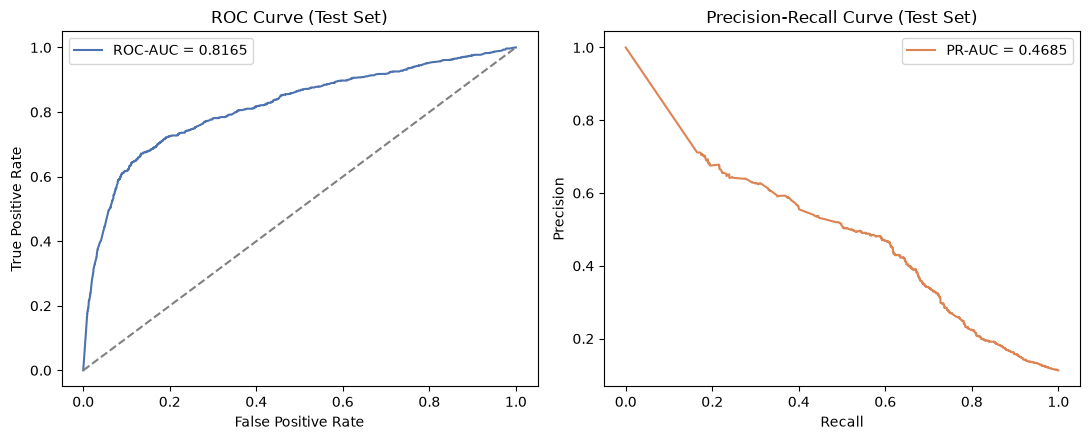

In [45]:
fpr, tpr, _ = roc_curve(y_test, y_proba_test)
precision_curve, recall_curve, _ = precision_recall_curve(y_test, y_proba_test)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].plot(fpr, tpr, color='#4C72B0', label=f'ROC-AUC = {roc_auc_test:.4f}')
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve (Test Set)')
axes[0].legend()

axes[1].plot(recall_curve, precision_curve, color='#DD8452', label=f'PR-AUC = {pr_auc_test:.4f}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.show()

Model final **LightGBM x ROS** dievaluasi sekali pada test set yang sudah dikunci sejak E.2 (8.236 nasabah, threshold default 0,5). Dari 928 nasabah yang benar-benar subscribe di test set, model berhasil menangkap 613 nasabah (Recall 66,06%) dan melewatkan 315 nasabah (False Negative). Dari 1.561 nasabah yang diprediksi akan subscribe, 613 di antaranya benar (Precision 39,27%), sisanya 948 adalah panggilan yang berujung sia-sia (False Positive). ROC-AUC 0,8165 dan PR-AUC 0,4685 menunjukkan kemampuan model membedakan kelas subscribe dan tidak jauh di atas model acak, konsisten dengan technical goal A.5 poin 1 yang menuntut model menghasilkan skor probabilitas yang bisa dipakai meranking nasabah, bukan sekadar label ya/tidak pada threshold tunggal.

### E.9 Threshold Optimization (Profit-Based)

Sejauh ini seleksi model (E.5-E.7) memakai F2 sebagai proxy murah untuk cross-validation, sesuai alasan di A.5. Tapi keputusan akhir soal threshold, berapa skor probabilitas minimum supaya nasabah dihubungi, seharusnya memakai ukuran yang langsung merepresentasikan business goal A.3: net profit. Cost framework A.4 dipakai persis seperti yang sudah dikoreksi di sana: TP = +Rp 450.000, FP = -Rp 50.000, FN = -Rp 500.000, TN = Rp 0.

In [46]:
thresholds = np.arange(0.01, 1.00, 0.01)
sweep_rows = []

for t in thresholds:
    y_pred_t = (y_proba_test >= t).astype(int)
    cm_t = confusion_matrix(y_test, y_pred_t)
    tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
    profit_t = tp_t * 450_000 - fp_t * 50_000 - fn_t * 500_000
    f2_t = fbeta_score(y_test, y_pred_t, beta=2, zero_division=0)
    recall_t = recall_score(y_test, y_pred_t, zero_division=0)
    precision_t = precision_score(y_test, y_pred_t, zero_division=0)
    calls_t = tp_t + fp_t
    sweep_rows.append({
        'threshold': t, 'tp': tp_t, 'fp': fp_t, 'fn': fn_t, 'tn': tn_t,
        'profit': profit_t, 'f2': f2_t, 'recall': recall_t, 'precision': precision_t, 'calls': calls_t
    })

threshold_sweep = pd.DataFrame(sweep_rows)

idx_profit_optimal = threshold_sweep['profit'].idxmax()
idx_f2_optimal = threshold_sweep['f2'].idxmax()

profit_optimal_threshold = threshold_sweep.loc[idx_profit_optimal, 'threshold']
f2_optimal_threshold = threshold_sweep.loc[idx_f2_optimal, 'threshold']

print(f"Threshold profit-optimal : {profit_optimal_threshold:.2f} (profit = Rp {threshold_sweep.loc[idx_profit_optimal, 'profit']:,.0f})")
print(f"Threshold F2-optimal     : {f2_optimal_threshold:.2f} (F2 = {threshold_sweep.loc[idx_f2_optimal, 'f2']:.4f})")

Threshold profit-optimal : 0.33 (profit = Rp 117,350,000)
Threshold F2-optimal     : 0.49 (F2 = 0.5860)


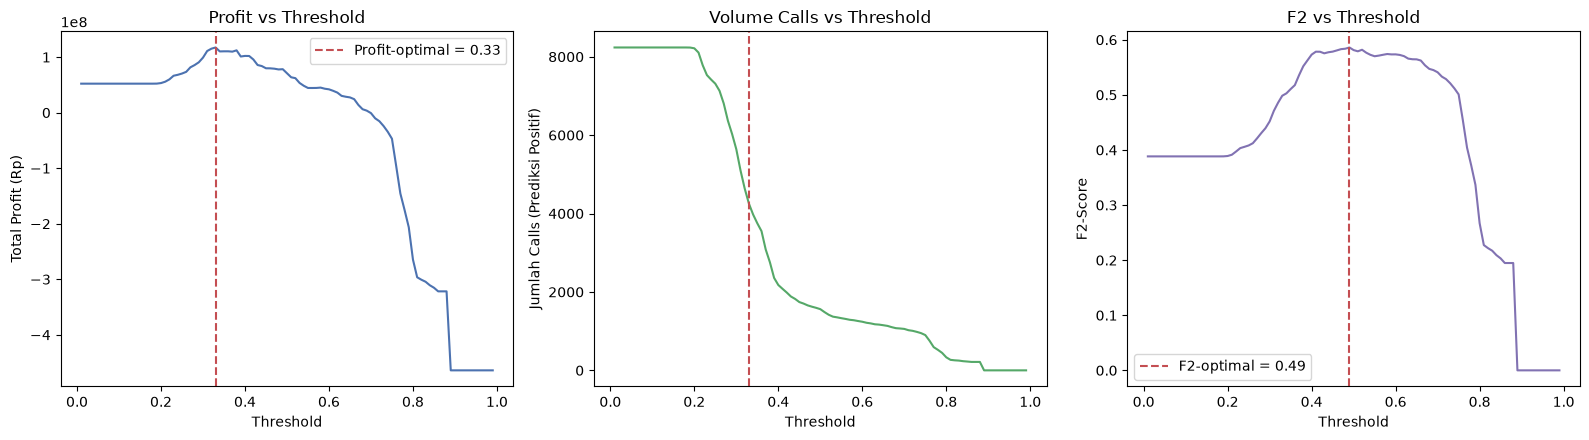

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].plot(threshold_sweep['threshold'], threshold_sweep['profit'], color='#4C72B0')
axes[0].axvline(profit_optimal_threshold, color='#C44E52', linestyle='--',
                label=f'Profit-optimal = {profit_optimal_threshold:.2f}')
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Profit (Rp)')
axes[0].set_title('Profit vs Threshold')
axes[0].legend()

axes[1].plot(threshold_sweep['threshold'], threshold_sweep['calls'], color='#55A868')
axes[1].axvline(profit_optimal_threshold, color='#C44E52', linestyle='--')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Jumlah Calls (Prediksi Positif)')
axes[1].set_title('Volume Calls vs Threshold')

axes[2].plot(threshold_sweep['threshold'], threshold_sweep['f2'], color='#8172B2')
axes[2].axvline(f2_optimal_threshold, color='#C44E52', linestyle='--',
                label=f'F2-optimal = {f2_optimal_threshold:.2f}')
axes[2].set_xlabel('Threshold')
axes[2].set_ylabel('F2-Score')
axes[2].set_title('F2 vs Threshold')
axes[2].legend()

plt.tight_layout()
plt.show()

Threshold profit-optimal murni di atas memang menghasilkan profit tertinggi secara matematis, tapi perlu dicek dulu apa konsekuensinya di lapangan sebelum dipakai sebagai rekomendasi deployment. Rasio cost framework A.4 antara TP (+Rp450rb) dan FP (-Rp50rb) sekitar 9:1, dan rasio itu membuat profit murni cenderung "menebar jala lebar", menghubungi sebanyak mungkin nasabah selama peluangnya masih positif, karena satu FP yang salah jauh lebih murah dibanding satu TP yang terlewat. Konsekuensinya terlihat di tabel perbandingan sebelumnya: threshold profit-optimal murni menuntut volume panggilan yang sangat besar dengan precision yang rendah.

Profit murni sebagai fungsi objektif tidak tahu bahwa call center punya kapasitas terbatas dan bahwa panggilan sia-sia punya ongkos yang tidak masuk cost framework A.4 secara eksplisit (waktu dan tenaga agen, potensi mengganggu nasabah yang jelas tidak berminat, risiko reputasi). Bagian berikut memodelkan keterbatasan itu lewat dua sudut pandang independen, supaya threshold final untuk deployment tidak murni mengikuti angka matematis tanpa mempertimbangkan realitas operasional.

#### Lensa 1: Titik Diminishing Returns (Knee Point)

In [48]:
pc = threshold_sweep.sort_values('threshold', ascending=False).reset_index(drop=True)
calls_arr = pc['calls'].values.astype(float)
profit_arr = pc['profit'].values.astype(float)

calls_norm = (calls_arr - calls_arr.min()) / (calls_arr.max() - calls_arr.min())
profit_norm = (profit_arr - profit_arr.min()) / (profit_arr.max() - profit_arr.min())

x1, y1 = calls_norm[0], profit_norm[0]
x2, y2 = calls_norm[-1], profit_norm[-1]
numerator = np.abs((y2 - y1) * calls_norm - (x2 - x1) * profit_norm + x2 * y1 - y2 * x1)
denominator = np.sqrt((y2 - y1) ** 2 + (x2 - x1) ** 2)
distance_to_chord = numerator / denominator

knee_idx = distance_to_chord.argmax()
knee_row = pc.iloc[knee_idx]
knee_threshold = knee_row['threshold']

print(f"Titik knee (jarak terjauh dari garis lurus awal-akhir kurva profit vs calls):")
print(f"Threshold  : {knee_threshold:.2f}")
print(f"Calls      : {knee_row['calls']:.0f} ({knee_row['calls'] / len(X_test) * 100:.1f}% dari test set)")
print(f"Profit     : Rp {knee_row['profit']:,.0f}")
print(f"Precision  : {knee_row['precision'] * 100:.2f}%")
print(f"Recall     : {knee_row['recall'] * 100:.2f}%")
print(f"F2         : {knee_row['f2']:.4f}")

Titik knee (jarak terjauh dari garis lurus awal-akhir kurva profit vs calls):
Threshold  : 0.49
Calls      : 1595 (19.4% dari test set)
Profit     : Rp 78,250,000
Precision  : 39.00%
Recall     : 67.03%
F2         : 0.5860


Metode yang dipakai untuk menemukan titik knee adalah jarak maksimum ke garis lurus (metode kneedle): kurva profit terhadap jumlah calls diurutkan dari threshold tertinggi (calls sedikit) ke threshold terendah (calls banyak), dinormalisasi ke skala 0-1 di kedua sumbu, lalu dibuat garis lurus imajiner dari titik pertama ke titik terakhir kurva. Titik knee adalah titik pada kurva asli yang jaraknya paling jauh dari garis itu, karena di situlah kurva paling "melengkung", tanda bahwa penambahan calls setelah titik itu tidak lagi sebanding dengan tambahan profit yang dihasilkan (diminishing returns). Hasil di atas menunjukkan threshold, volume calls, dan metrik lain tepat di titik itu, dihitung langsung dari `threshold_sweep`, bukan dikira-kira.

#### Lensa 2: Precision Floor (Cross-Check)

In [49]:
precision_floor = 0.30

eligible = threshold_sweep[threshold_sweep['precision'] >= precision_floor]
precision_floor_row = eligible.loc[eligible['threshold'].idxmin()]
precision_floor_threshold = precision_floor_row['threshold']

print(f"Threshold precision-floor (precision >= {precision_floor * 100:.0f}%, paling longgar yang masih memenuhi):")
print(f"Threshold  : {precision_floor_threshold:.2f}")
print(f"Calls      : {precision_floor_row['calls']:.0f} ({precision_floor_row['calls'] / len(X_test) * 100:.1f}% dari test set)")
print(f"Profit     : Rp {precision_floor_row['profit']:,.0f}")
print(f"Precision  : {precision_floor_row['precision'] * 100:.2f}%")
print(f"Recall     : {precision_floor_row['recall'] * 100:.2f}%")

Threshold precision-floor (precision >= 30%, paling longgar yang masih memenuhi):
Threshold  : 0.40
Calls      : 2177 (26.4% dari test set)
Profit     : Rp 102,150,000
Precision  : 31.01%
Recall     : 72.74%


Ambang precision 30% dipilih bukan angka sembarang: baseline conversion rate populasi keseluruhan sekitar 11,3% (dari A.2), jadi precision 30% berarti kampanye ini kira-kira 2,7 kali lebih efisien dibanding menghubungi nasabah secara acak tanpa model sama sekali, ambang yang wajar dituntut dari kampanye yang katanya bertarget. Dari seluruh threshold yang precision-nya masih di atas 30%, dipilih yang paling longgar (threshold terendah dalam kelompok itu), supaya volume panggilan dan profitnya semaksimal mungkin tanpa melanggar batas precision.

Alasan memilih lensa precision sebagai cross-check: cost framework A.4 menilai FP hanya -Rp50rb, angka yang mewakili biaya langsung satu panggilan, tapi tidak menangkap ongkos non-moneter dari panggilan yang sia-sia, beban kerja agen yang menumpuk, potensi mengganggu nasabah yang jelas tidak berminat, dan risiko reputasi kalau kampanye terkesan asal tebar. Menuntut precision minimum adalah cara memasukkan pertimbangan itu ke keputusan threshold tanpa harus mengubah cost framework itu sendiri.

#### Konvergensi dan Threshold Final Deployment

In [50]:
corridor_low = min(knee_threshold, precision_floor_threshold)
corridor_high = max(knee_threshold, precision_floor_threshold)

corridor_mask = (threshold_sweep['threshold'] >= corridor_low) & (threshold_sweep['threshold'] <= corridor_high)
corridor_df = threshold_sweep[corridor_mask]

best_corridor_idx = corridor_df['profit'].idxmax()
threshold_deployment = threshold_sweep.loc[best_corridor_idx, 'threshold']

deployment_row = threshold_sweep.loc[(threshold_sweep['threshold'] - threshold_deployment).abs().idxmin()]

convergence_note = (
    f"Kedua lensa tidak menunjuk titik persis yang sama (knee di {knee_threshold:.2f}, precision-floor di "
    f"{precision_floor_threshold:.2f}), tapi keduanya tetap saling melengkapi: bukan sebagai dua kandidat yang harus "
    f"dipilih salah satu, melainkan sebagai dua batas yang bersama-sama mendefinisikan sebuah koridor threshold sehat "
    f"antara {corridor_low:.2f} dan {corridor_high:.2f}. Precision-floor menjadi ujung paling agresif dari koridor ini "
    f"(masih memenuhi precision minimum yang sehat), knee menjadi ujung paling selektif (volume call paling sedikit, "
    f"precision paling tinggi). Karena business goal A.3 menuntut net profit dimaksimalkan, dan profit di dalam "
    f"koridor ini masih naik saat threshold diturunkan menuju ujung precision-floor, titik yang dipilih adalah profit "
    f"tertinggi di dalam koridor tersebut, bukan titik paling konservatif."
)

print(convergence_note)
print(f"\nKoridor threshold sehat: {corridor_low:.2f} - {corridor_high:.2f}")
print(f"Threshold final deployment: {threshold_deployment:.2f}")
print(f"Calls     : {deployment_row['calls']:.0f} ({deployment_row['calls'] / len(X_test) * 100:.1f}% dari test set)")
print(f"Profit    : Rp {deployment_row['profit']:,.0f}")
print(f"Precision : {deployment_row['precision'] * 100:.2f}%")
print(f"Recall    : {deployment_row['recall'] * 100:.2f}%")
print(f"F2        : {deployment_row['f2']:.4f}")

Kedua lensa tidak menunjuk titik persis yang sama (knee di 0.49, precision-floor di 0.40), tapi keduanya tetap saling melengkapi: bukan sebagai dua kandidat yang harus dipilih salah satu, melainkan sebagai dua batas yang bersama-sama mendefinisikan sebuah koridor threshold sehat antara 0.40 dan 0.49. Precision-floor menjadi ujung paling agresif dari koridor ini (masih memenuhi precision minimum yang sehat), knee menjadi ujung paling selektif (volume call paling sedikit, precision paling tinggi). Karena business goal A.3 menuntut net profit dimaksimalkan, dan profit di dalam koridor ini masih naik saat threshold diturunkan menuju ujung precision-floor, titik yang dipilih adalah profit tertinggi di dalam koridor tersebut, bukan titik paling konservatif.

Koridor threshold sehat: 0.40 - 0.49
Threshold final deployment: 0.40
Calls     : 2177 (26.4% dari test set)
Profit    : Rp 102,150,000
Precision : 31.01%
Recall    : 72.74%
F2        : 0.5731


#### Tabel dan Visual Perbandingan Tiga Skenario

In [51]:
scenario_thresholds = {
    'F2-optimal': f2_optimal_threshold,
    'Profit-optimal murni': profit_optimal_threshold,
    'Profit-optimal terbatas kapasitas (deployment)': threshold_deployment,
}

scenario_rows = []
for label, t in scenario_thresholds.items():
    row = threshold_sweep.loc[(threshold_sweep['threshold'] - t).abs().idxmin()]
    scenario_rows.append({
        'skenario': label, 'threshold': row['threshold'], 'f2': row['f2'],
        'recall': row['recall'], 'precision': row['precision'],
        'calls': row['calls'], 'calls_pct_database': row['calls'] / len(X_test) * 100,
        'profit_rp': row['profit']
    })

threshold_comparison = pd.DataFrame(scenario_rows)
threshold_comparison

,skenario,threshold,f2,recall,precision,calls,calls_pct_database,profit_rp
0,F2-optimal,0.49,0.586018,0.670259,0.389969,1595.0,19.366197,78250000.0
1,Profit-optimal murni,0.33,0.498431,0.855603,0.186692,4253.0,51.639145,117350000.0
2,Profit-optimal terbatas kapasitas (deployment),0.40,0.573102,0.727371,0.310060,2177.0,26.432734,102150000.0


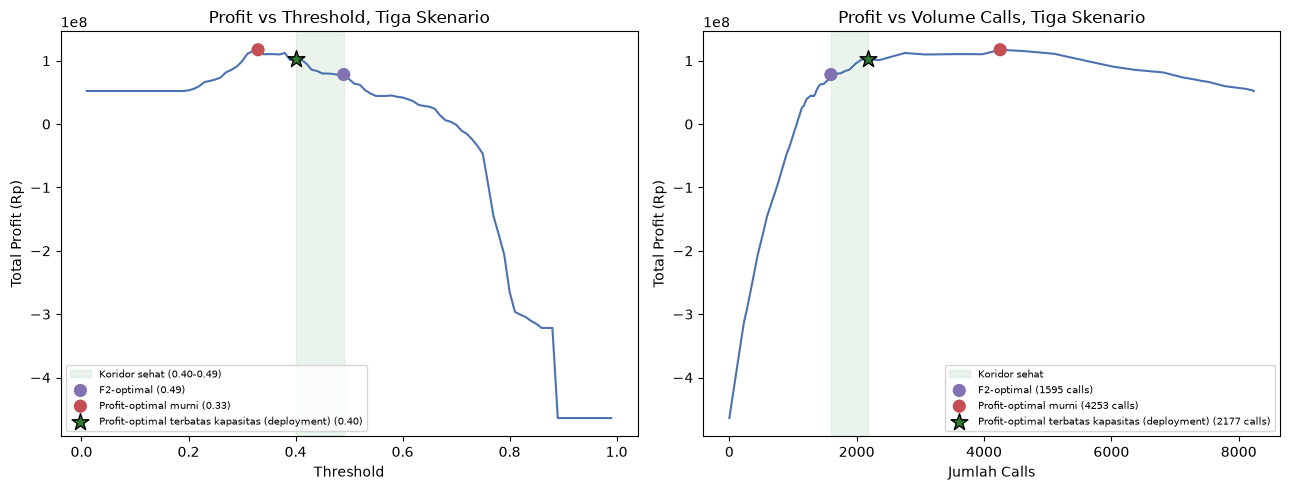

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(threshold_sweep['threshold'], threshold_sweep['profit'], color='#4C72B0')
axes[1].plot(threshold_sweep['calls'], threshold_sweep['profit'], color='#4C72B0')

corridor_calls_low = threshold_sweep.loc[(threshold_sweep['threshold'] - corridor_low).abs().idxmin(), 'calls']
corridor_calls_high = threshold_sweep.loc[(threshold_sweep['threshold'] - corridor_high).abs().idxmin(), 'calls']

axes[0].axvspan(corridor_low, corridor_high, color='#55A868', alpha=0.12, label=f'Koridor sehat ({corridor_low:.2f}-{corridor_high:.2f})')
axes[1].axvspan(min(corridor_calls_low, corridor_calls_high), max(corridor_calls_low, corridor_calls_high),
                 color='#55A868', alpha=0.12, label='Koridor sehat')

colors = {'F2-optimal': '#8172B2', 'Profit-optimal murni': '#C44E52', 'Profit-optimal terbatas kapasitas (deployment)': '#2E7D32'}
for _, row in threshold_comparison.iterrows():
    is_deployment = row['skenario'] == 'Profit-optimal terbatas kapasitas (deployment)'
    marker_size = 160 if is_deployment else 90
    marker_style = '*' if is_deployment else 'o'
    axes[0].scatter(row['threshold'], row['profit_rp'], color=colors[row['skenario']], s=marker_size, marker=marker_style,
                     zorder=5, edgecolors='black' if is_deployment else 'none',
                     label=f"{row['skenario']} ({row['threshold']:.2f})")
    axes[1].scatter(row['calls'], row['profit_rp'], color=colors[row['skenario']], s=marker_size, marker=marker_style,
                     zorder=5, edgecolors='black' if is_deployment else 'none',
                     label=f"{row['skenario']} ({row['calls']:.0f} calls)")

axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Total Profit (Rp)')
axes[0].set_title('Profit vs Threshold, Tiga Skenario')
axes[0].legend(fontsize=7.5)

axes[1].set_xlabel('Jumlah Calls')
axes[1].set_ylabel('Total Profit (Rp)')
axes[1].set_title('Profit vs Volume Calls, Tiga Skenario')
axes[1].legend(fontsize=7.5)

plt.tight_layout()
plt.show()

In [53]:
f2opt_row = threshold_comparison[threshold_comparison['skenario'] == 'F2-optimal'].iloc[0]
profmurni_row = threshold_comparison[threshold_comparison['skenario'] == 'Profit-optimal murni'].iloc[0]
deploy_row = threshold_comparison[threshold_comparison['skenario'] == 'Profit-optimal terbatas kapasitas (deployment)'].iloc[0]

profit_left_on_table_at_knee = deploy_row['profit_rp'] - f2opt_row['profit_rp']
profit_sacrificed_vs_murni = profmurni_row['profit_rp'] - deploy_row['profit_rp']
profit_sacrificed_vs_murni_pct = profit_sacrificed_vs_murni / profmurni_row['profit_rp'] * 100

print(f"Profit deployment vs knee: selisih Rp {profit_left_on_table_at_knee:,.0f}")
print(f"Profit dikorbankan vs profit-optimal murni: Rp {profit_sacrificed_vs_murni:,.0f} ({profit_sacrificed_vs_murni_pct:.1f}%)")

Profit deployment vs knee: selisih Rp 23,900,000
Profit dikorbankan vs profit-optimal murni: Rp 15,200,000 (13.0%)


Dua lensa di atas tidak dipakai sebagai dua kandidat yang bersaing untuk dipilih salah satu, melainkan sebagai sepasang batas yang bersama-sama mendefinisikan **koridor threshold sehat**, dari 0,40 (precision-floor, ujung paling agresif yang precision-nya masih di atas 30%) sampai 0,49 (knee, ujung paling selektif dengan volume call paling sedikit). Di dalam koridor ini, precision terjamin sehat di kedua ujung, jadi keputusan berikutnya bisa murni mengikuti business goal A.3: maksimalkan net profit. Karena profit masih naik saat threshold diturunkan dari 0,49 menuju 0,40, titik profit tertinggi di dalam koridor ada di ujung precision-floor.

**Threshold final untuk deployment: 0,40**. Pada threshold ini, model merekomendasikan 2.177 panggilan (26,4% dari database test set), dengan Precision 31,01% (masih di atas ambang sehat 30%, sekitar 2,8 kali baseline conversion rate populasi 11,3% dari A.2) dan Recall 72,74%, menghasilkan profit Rp 102.150.000.

Dua ujung lain ditolak dengan alasan berbeda. Threshold profit-optimal murni (0,33) memang menghasilkan profit tertinggi secara matematis, Rp 117.350.000, tapi menuntut menghubungi 4.253 nasabah (51,6% dari test set) dengan precision hanya 18,7%, bertentangan dengan fungsi prioritisasi kampanye dan mengabaikan kapasitas call center. Sebaliknya threshold knee (0,49), meski paling selektif, meninggalkan sekitar Rp 23.900.000 profit di atas meja dibanding threshold deployment, tanpa manfaat operasional yang sepadan, karena 26,4% database di threshold deployment masih realistis untuk kapasitas call center yang wajar.

Dibanding threshold profit-optimal murni, threshold deployment ini tetap mengorbankan sekitar Rp 15.200.000 (13,0%) dari profit teoretis tertinggi. Ini keputusan bisnis yang sadar dengan pagar di kedua sisi, precision-floor mencegah pemborosan panggilan sia-sia, knee menandai batas paling selektif, dan di antara keduanya dipilih titik dengan alasan profit yang jelas, konsisten dengan tema prioritisasi di bawah keterbatasan sumber daya yang juga muncul di D.4 (alokasi budget bulanan). Memilih titik dalam koridor sehat yang memaksimalkan profit adalah wujud konkret dari prioritisasi itu: dari sekian nasabah, hubungi yang probabilitas skornya tertinggi dulu sampai kapasitas operasional yang realistis habis, bukan menghubungi siapa pun yang skornya di atas nol secara matematis.

### E.10 Feature Importance & SHAP

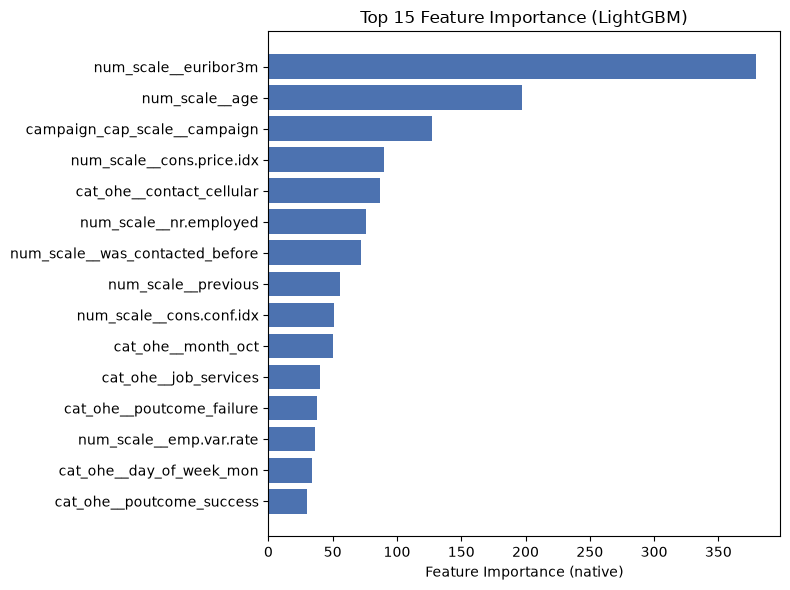

,feature,importance
0,num_scale__euribor3m,379
1,num_scale__age,197
2,campaign_cap_scale__campaign,127
3,num_scale__cons.price.idx,90
4,cat_ohe__contact_cellular,87
5,num_scale__nr.employed,76
6,num_scale__was_contacted_before,72
7,num_scale__previous,56
8,num_scale__cons.conf.idx,51
9,cat_ohe__month_oct,50


In [54]:
import shap

fitted_preprocessor = final_pipeline.named_steps['preprocess']
fitted_clf = final_pipeline.named_steps['clf']
feature_names_out = fitted_preprocessor.get_feature_names_out()

X_test_transformed = fitted_preprocessor.transform(X_test)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names_out)

tree_based = hasattr(fitted_clf, 'feature_importances_')

if tree_based:
    importance_df = pd.DataFrame({
        'feature': feature_names_out,
        'importance': fitted_clf.feature_importances_
    }).sort_values('importance', ascending=False).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(8, 6))
    top_n = importance_df.head(15)
    ax.barh(top_n['feature'][::-1], top_n['importance'][::-1], color='#4C72B0')
    ax.set_xlabel('Feature Importance (native)')
    ax.set_title(f'Top 15 Feature Importance ({final_model_name})')
    plt.tight_layout()
    plt.show()

    display(importance_df.head(10))
else:
    print(f"{final_model_name} tidak punya feature_importances_ native (bukan model tree-based), lanjut ke SHAP.")

In [55]:
sample_size = min(1000, X_test_transformed_df.shape[0])
X_sample = X_test_transformed_df.sample(n=sample_size, random_state=42)

if tree_based:
    explainer = shap.TreeExplainer(fitted_clf)
    shap_values = explainer.shap_values(X_sample)
    if isinstance(shap_values, list):
        shap_values_plot = shap_values[1]
    elif shap_values.ndim == 3:
        shap_values_plot = shap_values[:, :, 1]
    else:
        shap_values_plot = shap_values
else:
    explainer = shap.LinearExplainer(fitted_clf, X_test_transformed_df)
    shap_values_plot = explainer.shap_values(X_sample)

print(f"SHAP dihitung pada sampel {sample_size} baris test set (transformed), explainer: {type(explainer).__name__}")

SHAP dihitung pada sampel 1000 baris test set (transformed), explainer: TreeExplainer


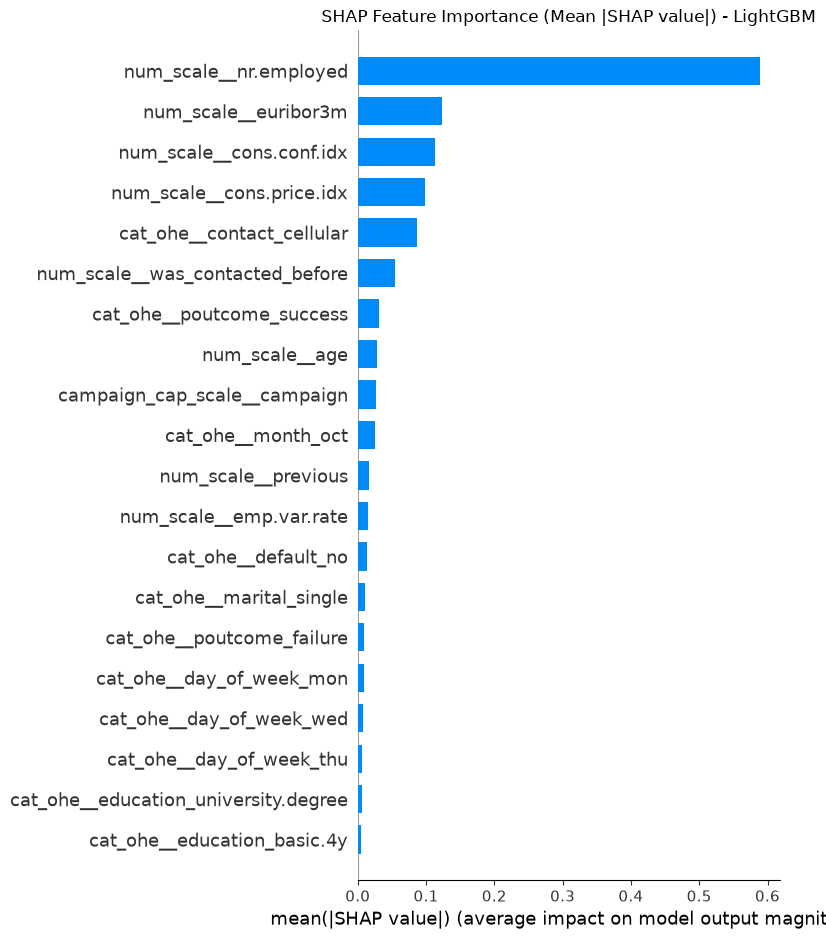

In [56]:
shap.summary_plot(shap_values_plot, X_sample, plot_type='bar', show=False)
plt.title(f'SHAP Feature Importance (Mean |SHAP value|) - {final_model_name}')
plt.tight_layout()
plt.show()

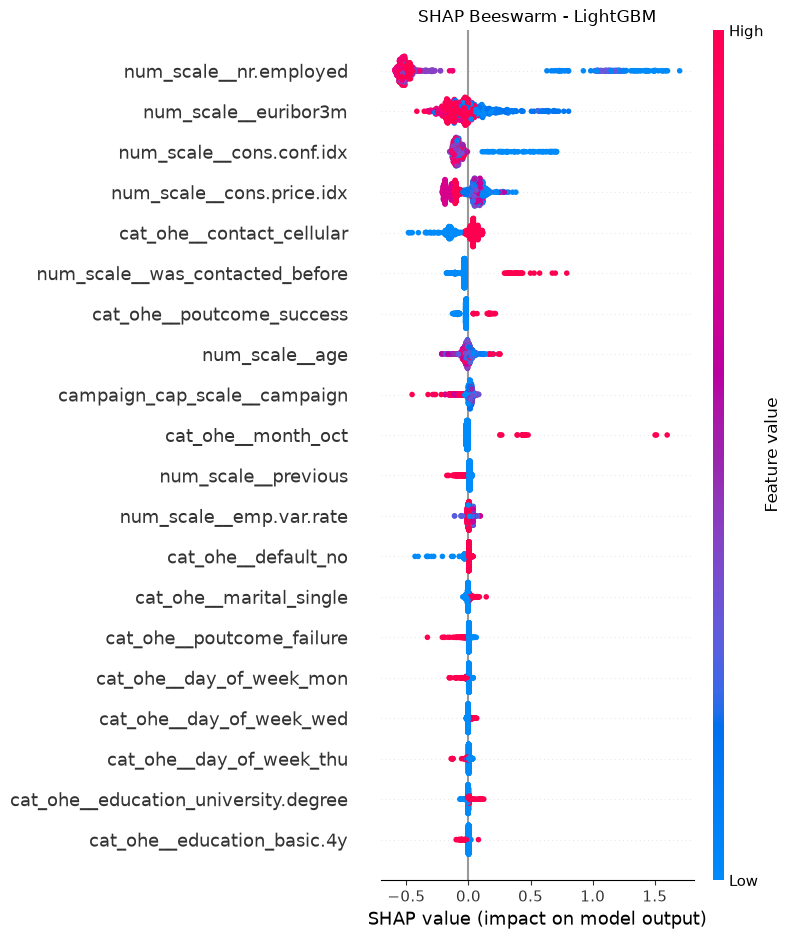

In [57]:
shap.summary_plot(shap_values_plot, X_sample, show=False)
plt.title(f'SHAP Beeswarm - {final_model_name}')
plt.tight_layout()
plt.show()

In [58]:
mean_abs_shap = pd.DataFrame({
    'feature': X_sample.columns,
    'mean_abs_shap': np.abs(shap_values_plot).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

top5_shap = mean_abs_shap.head(5)
top5_shap

,feature,mean_abs_shap
0,num_scale__nr.employed,0.588634
1,num_scale__euribor3m,0.123974
2,num_scale__cons.conf.idx,0.112933
3,num_scale__cons.price.idx,0.099147
4,cat_ohe__contact_cellular,0.087341


Lima fitur dengan mean |SHAP value| tertinggi: `nr.employed` (0,5886), `euribor3m` (0,1240), `cons.conf.idx` (0,1129), `cons.price.idx` (0,0991), `contact_cellular` (0,0873).

Mayoritas dari lima fitur teratas justru indikator makroekonomi (`cons.conf.idx`, `cons.price.idx`, `euribor3m`, `nr.employed`), konsisten dengan temuan D.5 bahwa euribor3m berkorelasi dengan subscribe rate. Ini juga langsung memunculkan catatan multikolinearitas dari D.6: emp.var.rate, euribor3m, dan nr.employed saling berkorelasi di atas 0,9, jadi importance yang terlihat besar pada satu fitur makro kemungkinan sebagian berasal dari sinyal yang terbagi dengan fitur makro lain yang berkorelasi, bukan berarti fitur makro lain yang skornya lebih rendah benar-benar tidak relevan.

Fitur channel kontak (`contact_cellular`) juga masuk lima besar, menguatkan temuan D.2 bahwa saluran kontak adalah prediktor kuat, bukan cuma beda rate deskriptif.

Menariknya, `poutcome` dan `was_contacted_before` tidak masuk lima besar SHAP di sini meski keduanya tercatat paling signifikan di uji Chi-Square D.7.1. Ini bisa terjadi karena Chi-Square mengukur asosiasi mentah dengan target, sementara SHAP mengukur kontribusi marjinal fitur itu terhadap prediksi model setelah fitur lain diperhitungkan bersama, jadi sinyal prediktif dari riwayat interaksi kemungkinan sudah banyak tertangkap lewat fitur makro dan channel yang berkorelasi dengan periode serta cara nasabah dihubungi.

### E.11 Menyimpan Model Final

Model final dan metadatanya disimpan ke folder `models/`, supaya bisa dipakai ulang di aplikasi Streamlit tanpa perlu melatih ulang dari nol. Pipeline yang disimpan mencakup seluruh langkah preprocessing (termasuk `CampaignCapper`), bukan cuma classifier-nya saja, supaya input mentah dari form Streamlit bisa langsung diproses tanpa transformasi manual tambahan.

In [59]:
import joblib
import json
import os

os.makedirs('models', exist_ok=True)

joblib.dump(final_pipeline, 'models/final_model.pkl')

metadata = {
    'model_name': final_model_name,
    'resampler_name': final_resampler_name,
    'best_params': {k: (v if not isinstance(v, (np.integer, np.floating)) else float(v)) for k, v in best_row['best_params'].items()},
    'threshold_deployment': float(threshold_deployment),
    'threshold_profit_optimal': float(profit_optimal_threshold),
    'threshold_f2_optimal': float(f2_optimal_threshold),
    'test_metrics': {
        'f2': float(f2_test),
        'recall': float(recall_test),
        'precision': float(precision_test),
        'roc_auc': float(roc_auc_test),
        'pr_auc': float(pr_auc_test),
    },
    'deployment_threshold_metrics': {
        'calls': float(deploy_row['calls']),
        'calls_pct_database': float(deploy_row['calls_pct_database']),
        'precision': float(deploy_row['precision']),
        'recall': float(deploy_row['recall']),
        'f2': float(deploy_row['f2']),
        'profit_rp': float(deploy_row['profit_rp']),
    },
    'profit_optimal_threshold_metrics': {
        'calls': float(profmurni_row['calls']),
        'calls_pct_database': float(profmurni_row['calls_pct_database']),
        'precision': float(profmurni_row['precision']),
        'recall': float(profmurni_row['recall']),
        'profit_rp': float(profmurni_row['profit_rp']),
    },
    'categorical_cols': categorical_cols,
    'numeric_cols': numeric_cols,
    'cost_framework': {
        'tp_rp': 450000,
        'tn_rp': 0,
        'fp_rp': -50000,
        'fn_rp': -500000,
    },
}

with open('models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model tersimpan di models/final_model.pkl")
print("Metadata tersimpan di models/model_metadata.json")
print(json.dumps(metadata, indent=2))

Model tersimpan di models/final_model.pkl
Metadata tersimpan di models/model_metadata.json
{
  "model_name": "LightGBM",
  "resampler_name": "ROS",
  "best_params": {
    "clf__learning_rate": 0.03161968666713354,
    "clf__max_depth": 8,
    "clf__n_estimators": 58,
    "clf__subsample": 0.908897907718663
  },
  "threshold_deployment": 0.4,
  "threshold_profit_optimal": 0.33,
  "threshold_f2_optimal": 0.49,
  "test_metrics": {
    "f2": 0.581263038118718,
    "recall": 0.6605603448275862,
    "precision": 0.39269698910954515,
    "roc_auc": 0.8164759215219977,
    "pr_auc": 0.4684724786064039
  },
  "deployment_threshold_metrics": {
    "calls": 2177.0,
    "calls_pct_database": 26.432734337056825,
    "precision": 0.3100597152044097,
    "recall": 0.7273706896551724,
    "f2": 0.5731023942944473,
    "profit_rp": 102150000.0
  },
  "profit_optimal_threshold_metrics": {
    "calls": 4253.0,
    "calls_pct_database": 51.63914521612433,
    "precision": 0.18669174700211616,
    "recall"

In [60]:
loaded_pipeline = joblib.load('models/final_model.pkl')
sanity_pred = loaded_pipeline.predict(X_test.head(5))
print("Sanity check, load ulang model dan prediksi 5 baris pertama X_test:")
print(sanity_pred)

Sanity check, load ulang model dan prediksi 5 baris pertama X_test:
[0 1 1 1 0]


## F. Business Impact & Optimization

### F.1 Menagih Baseline Net Profit

Di A.3, business goal menjanjikan baseline net profit (skenario menghubungi seluruh nasabah tanpa model) akan dihitung sebagai titik pembanding untuk semua klaim peningkatan yang diajukan project ini. Sekarang saatnya menagih janji itu, dengan test set yang sama dipakai untuk seluruh evaluasi model sebelumnya.

In [61]:
TP_baseline = int(y_test.sum())
FP_baseline = int(len(y_test) - TP_baseline)
profit_baseline = TP_baseline * 450_000 - FP_baseline * 50_000

print(f"Skenario baseline: hubungi seluruh {len(y_test)} nasabah di test set")
print(f"TP (subscribe, dapat margin bersih) : {TP_baseline}")
print(f"FP (tidak subscribe, call sia-sia)  : {FP_baseline}")
print(f"Profit baseline = {TP_baseline} x Rp450.000 - {FP_baseline} x Rp50.000 = Rp {profit_baseline:,.0f}")

Skenario baseline: hubungi seluruh 8236 nasabah di test set
TP (subscribe, dapat margin bersih) : 928
FP (tidak subscribe, call sia-sia)  : 7308
Profit baseline = 928 x Rp450.000 - 7308 x Rp50.000 = Rp 52,200,000


Baseline net profit dari menghubungi seluruh 8.236 nasabah tanpa model adalah **Rp 52.200.000**. Angka ini positif, karena margin bersih per nasabah yang berhasil dikonversi (Rp450rb) jauh lebih besar dibanding biaya satu panggilan (Rp50rb), jadi bahkan strategi paling naif pun tidak merugi secara agregat. Tapi pendekatan ini sangat tidak efisien: untuk menangkap 928 subscriber, tim harus menanggung 7.308 panggilan yang berujung sia-sia, hampir 89% dari seluruh kontak yang dilakukan. Inilah kondisi awal yang ingin diperbaiki lewat model.

### F.2 Net Profit dengan Model (Threshold Deployment)

In [62]:
deploy_full = threshold_sweep.loc[(threshold_sweep['threshold'] - threshold_deployment).abs().idxmin()]
TP_model = int(deploy_full['tp'])
FP_model = int(deploy_full['fp'])
FN_model = int(deploy_full['fn'])
profit_model = deploy_full['profit']
calls_model = int(deploy_full['calls'])
calls_baseline_count = len(y_test)

profit_increase_rp = profit_model - profit_baseline
profit_increase_pct = profit_increase_rp / profit_baseline * 100
calls_reduction_pct = (calls_baseline_count - calls_model) / calls_baseline_count * 100

print(f"Threshold deployment: {threshold_deployment:.2f}")
print(f"TP={TP_model}, FP={FP_model}, FN={FN_model}, calls={calls_model}")
print(f"Profit model: {TP_model} x Rp450.000 - {FP_model} x Rp50.000 - {FN_model} x Rp500.000 = Rp {profit_model:,.0f}")
print(f"\nKenaikan profit vs baseline : Rp {profit_increase_rp:,.0f} ({profit_increase_pct:.1f}%)")
print(f"Volume calls                : {calls_baseline_count} -> {calls_model} (turun {calls_reduction_pct:.1f}%)")

Threshold deployment: 0.40
TP=675, FP=1502, FN=253, calls=2177
Profit model: 675 x Rp450.000 - 1502 x Rp50.000 - 253 x Rp500.000 = Rp 102,150,000

Kenaikan profit vs baseline : Rp 49,950,000 (95.7%)
Volume calls                : 8236 -> 2177 (turun 73.6%)


Dengan model pada threshold deployment 0,40, net profit naik dari Rp 52.200.000 (F.1) menjadi **Rp 102.150.000**, kenaikan 95,7%, sekaligus volume panggilan turun dari seluruh 8.236 nasabah menjadi 2.177 nasabah saja, penurunan 73,6%.

Ini poin bisnis paling kuat dari project ini: model tidak cuma menaikkan profit, tapi menaikkannya SEKALIGUS memangkas beban operasional. Dua dimensi yang biasanya harus dikompromikan (lebih untung vs lebih hemat sumber daya) justru bergerak searah di sini, karena model membuang panggilan-panggilan yang paling kecil peluangnya sambil tetap menjaga sebagian besar subscriber tetap tertangkap.

### F.3 Dekomposisi & Efisiensi Kampanye

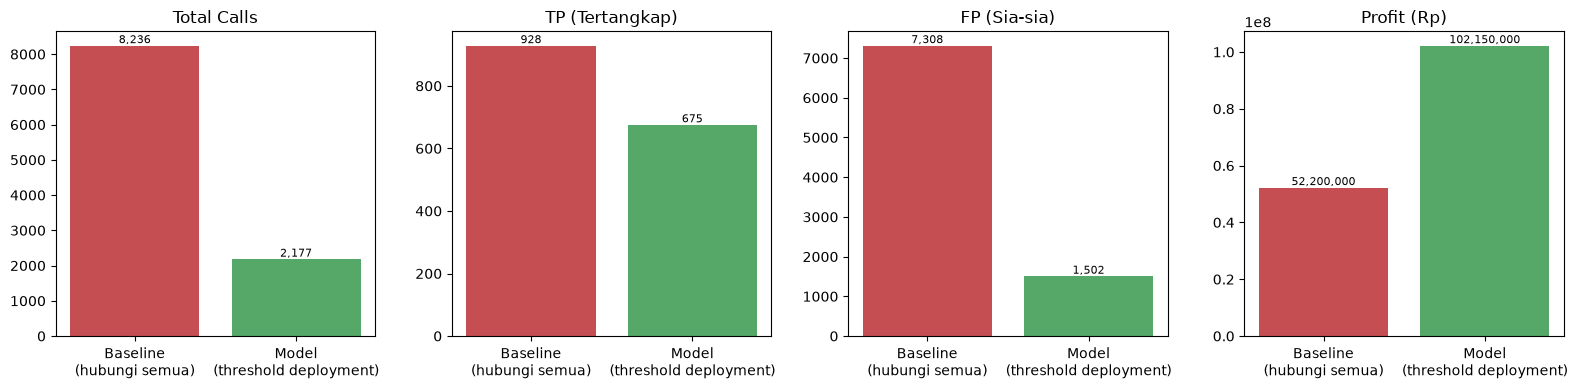

In [63]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

labels = ['Baseline\n(hubungi semua)', 'Model\n(threshold deployment)']
metrics_to_plot = [
    ('Total Calls', [calls_baseline_count, calls_model]),
    ('TP (Tertangkap)', [TP_baseline, TP_model]),
    ('FP (Sia-sia)', [FP_baseline, FP_model]),
    ('Profit (Rp)', [profit_baseline, profit_model]),
]

for ax, (title, values) in zip(axes, metrics_to_plot):
    ax.bar(labels, values, color=['#C44E52', '#55A868'])
    ax.set_title(title)
    for i, v in enumerate(values):
        ax.text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

In [64]:
recall_model_deploy = TP_model / (TP_model + FN_model)
print(f"Recall model (deployment): {recall_model_deploy * 100:.1f}%")
print(f"Proporsi volume calls terpakai: {calls_model / calls_baseline_count * 100:.1f}%")

Recall model (deployment): 72.7%
Proporsi volume calls terpakai: 26.4%


Grafik di atas meringkas dekomposisi baseline vs model dalam empat dimensi sekaligus. Model menangkap 72,7% dari seluruh subscriber potensial di test set (Recall), tapi hanya memakai 26,4% dari volume panggilan baseline. Diterjemahkan ke bahasa operasional: tim call center bisa fokus ke daftar prioritas yang jauh lebih pendek, sekitar seperempat dari database penuh, dan daftar pendek itu tetap berhasil menangkap mayoritas nasabah yang benar-benar berpotensi konversi. Sisa 73,6% nasabah yang tidak dihubungi sebagian besar memang berpeluang rendah, dikorbankan 253 subscriber potensial yang terlewat, tapi itu trade-off yang sudah diperhitungkan dalam cost framework A.4 dan threshold optimization di E.9.

### F.4 Ekstrapolasi ke Skala Kampanye Penuh

In [65]:
extrapolation_factor = len(X) / len(X_test)

profit_model_full = profit_model * extrapolation_factor
profit_baseline_full = profit_baseline * extrapolation_factor
calls_model_full = calls_model * extrapolation_factor
calls_baseline_full = calls_baseline_count * extrapolation_factor

print(f"Test set adalah {len(X_test) / len(X) * 100:.1f}% dari total data ({len(X_test)} dari {len(X)} baris)")
print(f"Faktor ekstrapolasi: {extrapolation_factor:.2f}x")
print(f"\nProfit model diekstrapolasi ke skala penuh : Rp {profit_model_full:,.0f}")
print(f"Profit baseline diekstrapolasi ke skala penuh: Rp {profit_baseline_full:,.0f}")
print(f"Volume calls model diekstrapolasi             : {calls_model_full:,.0f} (dari total populasi {calls_baseline_full:,.0f})")

Test set adalah 20.0% dari total data (8236 dari 41176 baris)
Faktor ekstrapolasi: 5.00x

Profit model diekstrapolasi ke skala penuh : Rp 510,700,389
Profit baseline diekstrapolasi ke skala penuh: Rp 260,974,648
Volume calls model diekstrapolasi             : 10,884 (dari total populasi 41,176)


Test set yang dipakai sepanjang evaluasi model dan analisis dampak bisnis ini adalah 20,0% dari total data (8.236 dari 41.176 baris), jadi kalau pola yang sama diasumsikan berlaku untuk satu siklus kampanye penuh (skala 5 kali lipat data test set), profit model bisa diproyeksikan sekitar **Rp 510.700.389**, dibanding baseline Rp 260.974.648.

Catatan kejujuran yang perlu digarisbawahi tegas: angka ekstrapolasi ini bersifat indikatif, dengan asumsi komposisi nasabah, tingkat konversi, dan kondisi makroekonomi pada kampanye skala penuh serupa dengan yang terekam di test set. Asumsi ini tidak dijamin berlaku, musim kampanye baru, perubahan suku bunga acuan (seperti dibahas di D.5), atau pergeseran profil nasabah bisa membuat hasil riil berbeda dari proyeksi. Angka Rp 510.700.389 ini sebaiknya diperlakukan sebagai proyeksi kasar untuk gambaran skala dampak, bukan angka pasti atau target yang dijamin tercapai.

### F.5 ROI Kampanye

In [66]:
biaya_kampanye_model = calls_model * 50_000
roi_model = profit_model / biaya_kampanye_model

print(f"Rumus: ROI = Net Profit / Biaya Kampanye")
print(f"Biaya kampanye = jumlah calls x Rp50.000 = {calls_model} x Rp50.000 = Rp {biaya_kampanye_model:,.0f}")
print(f"Net profit (F.2)                          = Rp {profit_model:,.0f}")
print(f"ROI = {profit_model:,.0f} / {biaya_kampanye_model:,.0f} = {roi_model:.4f} ({roi_model * 100:.1f}%)")

Rumus: ROI = Net Profit / Biaya Kampanye
Biaya kampanye = jumlah calls x Rp50.000 = 2177 x Rp50.000 = Rp 108,850,000
Net profit (F.2)                          = Rp 102,150,000
ROI = 102,150,000 / 108,850,000 = 0.9384 (93.8%)


ROI dihitung dengan rumus eksplisit: **ROI = Net Profit / Biaya Kampanye**, di mana biaya kampanye didefinisikan sebagai jumlah panggilan dikalikan biaya per call (Rp50.000, dari A.4), tanpa memperhitungkan biaya tetap lain di luar cost framework ini (infrastruktur, gaji tetap, dan sebagainya). Hasilnya, ROI kampanye pada threshold deployment adalah **93,8%**.

Satu asumsi penting perlu digarisbawahi: nilai TP (+Rp450rb) di cost framework A.4 sudah bersih, artinya biaya panggilan untuk nasabah yang berhasil dikonversi sudah dikurangkan lebih dulu (margin Rp500rb dikurangi biaya call Rp50rb). Sementara itu, biaya kampanye di rumus ROI ini menghitung ulang seluruh 2.177 panggilan termasuk yang berhasil, sehingga biaya call untuk TP secara teknis terhitung dua kali, sekali di dalam nilai TP bersih, sekali lagi di penyebut ROI. Karena itu, ROI di sini lebih tepat dibaca sebagai KPI operasional sederhana yang mudah dikomunikasikan ke direksi (seberapa besar hasil dibanding total biaya operasional call center yang dikeluarkan), bukan angka return ekonomi yang presisi secara akuntansi.

### F.6 Simulasi Threshold Interaktif

In [67]:
simulation_thresholds = [0.33, threshold_deployment, 0.49]
simulation_rows = []
for t in simulation_thresholds:
    row = threshold_sweep.loc[(threshold_sweep['threshold'] - t).abs().idxmin()]
    simulation_rows.append({
        'threshold': row['threshold'],
        'calls': int(row['calls']),
        'calls_pct_database': row['calls'] / len(X_test) * 100,
        'precision_%': row['precision'] * 100,
        'recall_%': row['recall'] * 100,
        'profit_rp': row['profit'],
    })

threshold_simulation = pd.DataFrame(simulation_rows)
threshold_simulation

,threshold,calls,calls_pct_database,precision_%,recall_%,profit_rp
0,0.33,4253,51.639145,18.669175,85.560345,117350000.0
1,0.40,2177,26.432734,31.005972,72.737069,102150000.0
2,0.49,1595,19.366197,38.996865,67.025862,78250000.0


Tabel di atas meringkas bagaimana profit dan volume call berubah di tiga titik threshold yang relevan (profit-optimal murni, deployment, dan knee). Threshold deployment 0,40 yang dipakai sekarang bukan angka yang kaku selamanya, kalau kapasitas call center BMS berubah (misalnya tim telemarketing bertambah atau berkurang), threshold ini bisa digeser di sepanjang tabel ini untuk menyesuaikan volume panggilan dengan kapasitas yang tersedia, dengan trade-off profit dan recall yang sudah terpetakan. Ini yang nanti dijadikan parameter yang bisa diatur di aplikasi Streamlit, supaya Tim Telemarketing atau CMO bisa mensimulasikan sendiri skenario threshold sesuai kebutuhan operasional terkini, tanpa harus melatih ulang model.

## G. Conclusion & Recommendation

### G.1 Kesimpulan

In [68]:
f2_at_deployment = deploy_full['f2']
recall_at_deployment = deploy_full['recall']
precision_at_deployment = deploy_full['precision']

print(f"F2 at deployment: {f2_at_deployment:.4f}")
print(f"Recall at deployment: {recall_at_deployment * 100:.1f}%")
print(f"Precision at deployment: {precision_at_deployment * 100:.1f}%")

F2 at deployment: 0.5731
Recall at deployment: 72.7%
Precision at deployment: 31.0%


Problem statement di A.2 menanyakan bagaimana memprediksi nasabah yang berpotensi membuka deposito berjangka, supaya BMS bisa meningkatkan efisiensi kampanye dari baseline conversion rate 11,27% (seluruh nasabah dihubungi tanpa prioritisasi). Project ini menjawabnya dengan model klasifikasi **LightGBM + ROS** (tuned di E.7), dievaluasi pada test set yang dikunci sejak E.2 dengan ROC-AUC 0,8165 dan PR-AUC 0,4685 (default threshold 0,5, dari E.8).

Pada threshold deployment 0,40 yang ditetapkan di E.9 lewat analisis koridor kapasitas, model mencapai F2 0,5731, Recall 72,7%, dan Precision 31,0%. Diterjemahkan ke angka bisnis (F.1-F.5): net profit naik dari baseline Rp 52.200.000 ke Rp 102.150.000 per test set (naik 95,7%, diproyeksikan sekitar Rp 510.700.389 pada skala kampanye penuh, angka proyeksi ini indikatif, lihat catatan hedge di F.4), sementara volume panggilan turun 73,6% dan ROI kampanye mencapai 93,8%.

Ini menjawab business goal A.3, memaksimalkan net profit, bukan sekadar metrik teknis yang berdiri sendiri. Setiap keputusan besar di notebook ini, F2 sebagai proxy seleksi model (A.5), cost framework dengan TP bernilai positif (A.4), threshold deployment yang mempertimbangkan kapasitas operasional (E.9), semuanya berangkat dari tujuan bisnis di A.3 lebih dulu, baru diturunkan jadi keputusan teknis, bukan sebaliknya.

### G.2 Rekomendasi Bisnis

In [69]:
cellular_rate = contact_summary.loc['cellular', 'subscribe_rate_%']
telephone_rate = contact_summary.loc['telephone', 'subscribe_rate_%']
poutcome_success_rate = poutcome_summary.loc['success', 'subscribe_rate_%']

top5_months = month_contribution.head(5)
top5_months_names = {'mar': 'Maret', 'apr': 'April', 'may': 'Mei', 'jun': 'Juni', 'jul': 'Juli',
                      'aug': 'Agustus', 'sep': 'September', 'oct': 'Oktober', 'nov': 'November', 'dec': 'Desember'}
top5_months_id = [top5_months_names[m] for m in top5_months.index]
top5_cumulative = top5_months['kontribusi_kumulatif_%'].iloc[-1]

print(f"Cellular rate: {cellular_rate:.1f}%, Telephone rate: {telephone_rate:.1f}%")
print(f"Poutcome success rate: {poutcome_success_rate:.1f}%")
print(f"Top 5 bulan: {top5_months_id}, kontribusi kumulatif: {top5_cumulative:.0f}%")

Cellular rate: 14.7%, Telephone rate: 5.2%
Poutcome success rate: 65.1%
Top 5 bulan: ['Mei', 'Agustus', 'Juli', 'Juni', 'April'], kontribusi kumulatif: 71%


Lima rekomendasi berikut semuanya berakar ke temuan spesifik di notebook ini, bukan saran generik:

1. **Prioritisasi kontak berbasis skor model.** Gunakan skor probabilitas dari model final, hubungi nasabah dengan skor di atas threshold 0,40 lebih dulu (E.9). Ini menggantikan pendekatan menghubungi nasabah secara berurutan tanpa prioritisasi yang jadi baseline di A.1.

2. **Segmen prioritas dari riwayat interaksi.** Nasabah dengan `poutcome='success'` (subscribe rate 65,1%, jauh di atas rata-rata populasi) dan `was_contacted_before=1` adalah target paling efisien (D.3, dikonfirmasi signifikan secara statistik di uji Chi-Square D.7.1). Jadikan daftar kontak ulang nasabah ini prioritas pertama sebelum menyasar prospek baru.

3. **Prioritaskan channel cellular.** Subscribe rate cellular (14,7%) jauh di atas telephone (5,2%) (D.2). Alihkan proporsi database kontak ke nomor seluler, kurangi ketergantungan pada saluran telepon rumah/kantor.

4. **Timing dan alokasi budget berbasis kontribusi absolut, bukan rate.** Alokasikan sekitar 71% anggaran kampanye ke lima bulan berkontribusi konversi terbesar (Mei, Agustus, Juli, Juni, April), bukan ke bulan ber-rate tinggi tapi bervolume kecil seperti Maret atau Desember (D.4). Ini rekomendasi yang paling berbeda dari intuisi awam (mengejar rate tertinggi), dan justru inilah kontribusi analitis paling bernilai dari notebook ini.

5. **Threshold sebagai parameter yang bisa disesuaikan.** Threshold deployment bisa digeser di dalam koridor sehat 0,40 sampai 0,49 (E.9) kalau kapasitas call center berubah, dengan trade-off profit dan recall yang sudah terpetakan di F.6, tanpa perlu melatih ulang model.

### G.3 Limitasi & Future Work

Beberapa keterbatasan perlu diakui secara terbuka:

- **Data observasional, bukan eksperimen acak.** Pola bulanan (D.4) dan efektivitas channel (D.2) bisa dipengaruhi keputusan kampanye masa lalu (intensitas kontak per bulan atau channel ditentukan oleh strategi lama, bukan uji coba acak), bukan murni hubungan sebab-akibat yang bisa langsung digeneralisasi ke kondisi masa depan yang berbeda.
- **Cost framework berbasis asumsi industri, bukan data internal BMS aktual.** Angka TP=+Rp450rb, FP=-Rp50rb, FN=-Rp500rb (A.4) diturunkan dari rentang biaya dan margin industri perbankan Indonesia secara umum, karena BMS adalah entitas ilustratif. Kalau BMS riil punya struktur biaya berbeda, seluruh angka dampak bisnis di sini perlu dihitung ulang dengan cost framework yang diperbarui, meski metodologinya (threshold optimization, analisis koridor kapasitas) tetap berlaku.
- **Fitur makroekonomi saling berkorelasi tinggi.** `emp.var.rate`, `euribor3m`, `nr.employed` berkorelasi di atas 0,9 (D.6), sehingga feature importance SHAP di E.10 perlu ditafsirkan hati-hati, sinyal makroekonomi kolektif penting, tapi kontribusi masing-masing fitur individual bisa terdistribusi tidak merata di antara mereka.
- **Model dilatih pada data historis periode tertentu.** Kalau kondisi pasar bergeser signifikan (misalnya siklus suku bunga acuan berbalik arah lagi seperti dibahas di A.1), performa model berpotensi menurun dan perlu retraining berkala, bukan sekali dilatih lalu dipakai selamanya.

Untuk pengembangan lanjutan:

- **A/B testing di produksi** untuk memvalidasi ROI nyata dibanding proyeksi F.4-F.5, karena performa di test set historis tidak selalu identik dengan performa di kampanye langsung.
- **Integrasi skor model ke sistem CRM** supaya Tim Telemarketing bisa langsung melihat skor prioritas tanpa proses manual.
- **Monitoring drift** pada fitur makroekonomi dan perilaku nasabah, supaya penurunan performa model bisa terdeteksi lebih awal sebelum berdampak ke bisnis.
- **Eksplorasi model tersegmentasi per demografi**, misalnya model terpisah untuk segmen usia produktif vs pensiunan, mengingat pola konversi yang berbeda ditemukan di D.1 dan D.7.2.